## STEP 1: Data Understanding - Telemetry Health Dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the telemetry health dataset
telemetry_df = pd.read_csv('Dataset/telemetry_health_dataset_v3.csv')

# Display the first few rows of the dataset
print("Telemetry Health Dataset - First 5 rows:")
display(telemetry_df.head())

Telemetry Health Dataset - First 5 rows:


,timestamp,osVersion,deviceAgeYears,usageType,diskType,ramCapacityGB,lastMaintenanceDays,fanCleaned,cpuUsage,cpuTemp,...,smartHealth,batteryHealth,batteryPower,fanRpm,healthScore,failureProbability,failureOccurred,riskLevel,predictedComponent,rootCause
0,2024-09-07 12:41:40,Windows 10,3.8,Office,SSD,16,236,No,19.08,54.59,...,76.97,81.75,11.55,2343,79.71,24.66,1,Medium,NaN,No issue detected
1,2023-11-12 13:53:26,Windows 10,2.4,Gaming,SSD,16,720,No,45.89,61.79,...,82.62,90.03,6.91,3228,56.73,43.09,0,Medium,NaN,No issue detected
2,2023-08-27 14:27:56,Unknown,2.2,Office,SSD,16,142,Yes,11.24,44.98,...,40.75,52.11,20.70,2410,63.16,46.96,0,Medium,Disk,SSD controller errors rising
3,2024-08-02 17:13:39,Windows Server 2022,2.2,Developer,HDD,32,218,No,58.07,76.79,...,80.93,85.75,10.07,3558,55.71,40.05,0,Medium,NaN,No issue detected
4,2023-07-13 10:38:22,Windows 10,7.4,Office,SSD,16,24,Yes,18.21,47.22,...,75.94,72.60,13.65,2507,78.96,25.43,1,Medium,NaN,No issue detected


In [3]:
# Dataset shape
print(f"Dataset Shape: {telemetry_df.shape}")

Dataset Shape: (200000, 28)


In [4]:
# Column names and data types
print("\nColumn Names and Data Types:")
display(telemetry_df.info())


Column Names and Data Types:


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   timestamp            200000 non-null  str    
 1   osVersion            200000 non-null  str    
 2   deviceAgeYears       200000 non-null  float64
 3   usageType            200000 non-null  str    
 4   diskType             200000 non-null  str    
 5   ramCapacityGB        200000 non-null  int64  
 6   lastMaintenanceDays  200000 non-null  int64  
 7   fanCleaned           200000 non-null  str    
 8   cpuUsage             200000 non-null  float64
 9   cpuTemp              200000 non-null  float64
 10  cpuPower             200000 non-null  float64
 11  gpuUsage             200000 non-null  float64
 12  gpuTemp              200000 non-null  float64
 13  ramUsage             200000 non-null  float64
 14  processCount         200000 non-null  int64  
 15  diskUsage            200000 

None

In [5]:
# Missing value analysis
print("\nMissing Values Analysis:")
display(telemetry_df.isnull().sum()[telemetry_df.isnull().sum() > 0].sort_values(ascending=False))


Missing Values Analysis:


predictedComponent    115747
dtype: int64

In [6]:
# Target distribution
# The target for this dataset is 'failureOccurred'
print("\nTarget Variable ('failureOccurred') Distribution:")
display(telemetry_df['failureOccurred'].value_counts())
print("\nTarget Variable ('failureOccurred') Percentage Distribution:")
display(telemetry_df['failureOccurred'].value_counts(normalize=True) * 100)


Target Variable ('failureOccurred') Distribution:


failureOccurred
0    113779
1     86221
Name: count, dtype: int64


Target Variable ('failureOccurred') Percentage Distribution:


failureOccurred
0    56.8895
1    43.1105
Name: proportion, dtype: float64

In [7]:
# Summary statistics for numerical features
print("\nSummary Statistics for Numerical Features:")
display(telemetry_df.describe())


Summary Statistics for Numerical Features:


,deviceAgeYears,ramCapacityGB,lastMaintenanceDays,cpuUsage,cpuTemp,cpuPower,gpuUsage,gpuTemp,ramUsage,processCount,diskUsage,diskReadSpeed,diskWriteSpeed,smartHealth,batteryHealth,batteryPower,fanRpm,healthScore,failureProbability,failureOccurred
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,3.129860,14.988100,148.432445,42.796742,62.662372,33.827533,31.279539,49.103209,50.654255,175.928870,48.605835,340.479105,289.472377,75.066638,73.884099,17.639578,3397.428670,62.598444,43.188876,0.431105
std,2.031679,8.175573,143.776647,26.432832,17.330861,19.280200,33.378969,20.100102,23.970428,66.220434,20.790742,167.652599,144.227120,15.346233,16.343109,10.154427,1161.052162,14.267909,19.802873,0.495232
min,0.000000,4.000000,0.000000,0.000000,25.890000,5.000000,0.000000,25.000000,5.810000,45.000000,0.180000,20.000000,15.000000,10.620000,12.500000,0.000000,1000.000000,20.190000,1.130000,0.000000
25%,1.500000,8.000000,43.000000,16.110000,47.700000,15.830000,6.050000,34.640000,28.280000,108.000000,31.380000,120.500000,103.800000,66.700000,65.290000,10.890000,2314.000000,51.350000,25.580000,0.000000
50%,2.700000,16.000000,103.000000,47.610000,62.600000,35.410000,15.520000,40.370000,50.500000,184.000000,47.490000,430.200000,358.100000,79.130000,78.270000,15.330000,3506.000000,60.600000,41.930000,0.000000
75%,4.300000,16.000000,207.000000,62.400000,73.130000,45.820000,71.100000,68.640000,69.010000,235.000000,62.210000,472.000000,401.700000,86.550000,86.180000,21.380000,4210.000000,76.340000,57.820000,1.000000
max,8.000000,32.000000,720.000000,100.000000,100.000000,80.000000,100.000000,95.000000,100.000000,344.000000,100.000000,558.600000,520.500000,100.000000,100.000000,60.000000,6000.000000,95.780000,100.000000,1.000000


## STEP 1: Data Understanding - AI4I Predictive Maintenance Dataset

In [8]:
# Load the AI4I Predictive Maintenance Dataset
ai4i_df = pd.read_csv('Dataset/ai4i2020.csv')

# Display the first few rows of the dataset
print("AI4I Predictive Maintenance Dataset - First 5 rows:")
display(ai4i_df.head())

AI4I Predictive Maintenance Dataset - First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
# Dataset shape
print(f"Dataset Shape: {ai4i_df.shape}")

Dataset Shape: (10000, 14)


In [10]:
# Column names and data types
print("\nColumn Names and Data Types:")
display(ai4i_df.info())


Column Names and Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: f

None

In [11]:
# Missing value analysis
print("\nMissing Values Analysis:")
display(ai4i_df.isnull().sum()[ai4i_df.isnull().sum() > 0].sort_values(ascending=False))


Missing Values Analysis:


Series([], dtype: int64)

In [12]:
# Target distribution
# The target for this dataset is 'Machine failure'
print("\nTarget Variable ('Machine failure') Distribution:")
display(ai4i_df['Machine failure'].value_counts())
print("\nTarget Variable ('Machine failure') Percentage Distribution:")
display(ai4i_df['Machine failure'].value_counts(normalize=True) * 100)


Target Variable ('Machine failure') Distribution:


Machine failure
0    9661
1     339
Name: count, dtype: int64


Target Variable ('Machine failure') Percentage Distribution:


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [13]:
# Summary statistics for numerical features
print("\nSummary Statistics for Numerical Features:")
display(ai4i_df.describe())


Summary Statistics for Numerical Features:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## STEP 2: Data Cleaning - Telemetry Health Dataset

In [14]:
# Create a copy to work on, preserving the original dataframe
telemetry_cleaned_df = telemetry_df.copy()

In [15]:
# Remove duplicates
initial_rows = telemetry_cleaned_df.shape[0]
telemetry_cleaned_df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - telemetry_cleaned_df.shape[0]
print(f"Number of duplicate rows removed: {duplicates_removed}")
print(f"Dataset shape after removing duplicates: {telemetry_cleaned_df.shape}")

Number of duplicate rows removed: 0
Dataset shape after removing duplicates: (200000, 28)


In [16]:
# Handle missing values
# Re-check missing values after dropping duplicates
missing_values = telemetry_cleaned_df.isnull().sum()[telemetry_cleaned_df.isnull().sum() > 0].sort_values(ascending=False)
print("\nMissing values before handling:")
display(missing_values)

# 'predictedComponent' has a very high number of missing values (over 50%)
# and is likely an output of a prior prediction, not a feature for *our* prediction.
# It also contains 'No issue detected' which might be a placeholder for missing data. It will be dropped.
if 'predictedComponent' in telemetry_cleaned_df.columns:
    telemetry_cleaned_df.drop('predictedComponent', axis=1, inplace=True)
    print("Dropped 'predictedComponent' due to high missing values and irrelevance for input features.")

# Convert 'timestamp' to datetime to extract features later if needed, and to handle potential missing values in it if any.
telemetry_cleaned_df['timestamp'] = pd.to_datetime(telemetry_cleaned_df['timestamp'], errors='coerce')

# For columns with 1 missing value, let's impute with median for numerical columns
# and mode for categorical columns, especially for the *features*.

# Numerical columns to impute with median (assuming these are input features)
numerical_cols_to_impute = [
    'diskWriteSpeed', 'smartHealth', 'batteryHealth', 'batteryPower', 'fanRpm',
    'deviceAgeYears', 'ramCapacityGB', 'lastMaintenanceDays', 'cpuUsage', 'cpuTemp',
    'cpuPower', 'gpuUsage', 'gpuTemp', 'ramUsage', 'processCount', 'diskUsage',
    'diskReadSpeed', 'healthScore', 'failureProbability'
]

for col in numerical_cols_to_impute:
    if col in telemetry_cleaned_df.columns and telemetry_cleaned_df[col].isnull().any():
        median_val = telemetry_cleaned_df[col].median()
        telemetry_cleaned_df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Categorical columns with missing values (1 entry each)
categorical_cols_to_impute = [
    'osVersion', 'usageType', 'diskType', 'fanCleaned'
]

for col in categorical_cols_to_impute:
    if col in telemetry_cleaned_df.columns and telemetry_cleaned_df[col].isnull().any():
        mode_val = telemetry_cleaned_df[col].mode()[0]
        telemetry_cleaned_df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

# As there is 1 missing value for 'failureOccurred', 'riskLevel', 'rootCause',
# it is highly probable that this single row has incomplete information across several output-related columns.
# Given it's only 1 row out of ~143k, it's safe to drop this row.
telemetry_cleaned_df.dropna(subset=['failureOccurred'], inplace=True)
print("Dropped rows with missing 'failureOccurred' values.")

print("\nMissing values after handling:")
display(telemetry_cleaned_df.isnull().sum()[telemetry_cleaned_df.isnull().sum() > 0].sort_values(ascending=False))


Missing values before handling:


predictedComponent    115747
dtype: int64

Dropped 'predictedComponent' due to high missing values and irrelevance for input features.


Dropped rows with missing 'failureOccurred' values.

Missing values after handling:


Series([], dtype: int64)

In [17]:
# Handle invalid values and ensure correct data types

# Check for any NaT (Not a Time) values in 'timestamp' after conversion
nat_timestamps = telemetry_cleaned_df['timestamp'].isnull().sum()
if nat_timestamps > 0:
    print(f"Found {nat_timestamps} invalid timestamp values, dropping these rows.")
    telemetry_cleaned_df.dropna(subset=['timestamp'], inplace=True)

# Review categorical columns for inconsistent entries or unexpected values
print("\nUnique values for categorical columns:")
for col in ['osVersion', 'usageType', 'diskType', 'fanCleaned', 'riskLevel', 'rootCause']:
    if col in telemetry_cleaned_df.columns:
        print(f"\n{col}: {telemetry_cleaned_df[col].unique()}")

# For 'fanCleaned', it's an object type with 'Yes' and 'No'. Convert to numerical (0/1)
if 'fanCleaned' in telemetry_cleaned_df.columns:
    telemetry_cleaned_df['fanCleaned'] = telemetry_cleaned_df['fanCleaned'].map({'Yes': 1, 'No': 0})
    print("Converted 'fanCleaned' to numerical (1=Yes, 0=No).")

print("\nData types after conversion:")
display(telemetry_cleaned_df.info())


Unique values for categorical columns:

osVersion: <StringArray>
[         'Windows 10',             'Unknown', 'Windows Server 2022',
          'Windows 11', 'Windows Server 2019']
Length: 5, dtype: str

usageType: <StringArray>
['Office', 'Gaming', 'Developer']
Length: 3, dtype: str

diskType: <StringArray>
['SSD', 'HDD']
Length: 2, dtype: str

fanCleaned: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

riskLevel: <StringArray>
['Medium', 'High', 'Low', 'Critical']
Length: 4, dtype: str

rootCause: <StringArray>
[                                                              'No issue detected',
                                                    'SSD controller errors rising',
                                                                 'CPU overheating',
                                                             'Battery degradation',
                                                        'Excessive CPU power draw',
                                                        

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   timestamp            200000 non-null  datetime64[us]
 1   osVersion            200000 non-null  str           
 2   deviceAgeYears       200000 non-null  float64       
 3   usageType            200000 non-null  str           
 4   diskType             200000 non-null  str           
 5   ramCapacityGB        200000 non-null  int64         
 6   lastMaintenanceDays  200000 non-null  int64         
 7   fanCleaned           200000 non-null  int64         
 8   cpuUsage             200000 non-null  float64       
 9   cpuTemp              200000 non-null  float64       
 10  cpuPower             200000 non-null  float64       
 11  gpuUsage             200000 non-null  float64       
 12  gpuTemp              200000 non-null  float64       
 13  ramUsage             2000

None

In [18]:
# Outlier detection using IQR for numerical features

# Identify numerical columns for outlier detection. Exclude 'timestamp' and the target.
numerical_cols = telemetry_cleaned_df.select_dtypes(include=np.number).columns.tolist()

# Remove target and output related columns if they are in numerical_cols
# Also remove columns that are derived or identifiers not directly used for outlier analysis in features
if 'failureOccurred' in numerical_cols: numerical_cols.remove('failureOccurred')
if 'healthScore' in numerical_cols: numerical_cols.remove('healthScore')
if 'failureProbability' in numerical_cols: numerical_cols.remove('failureProbability')
if 'fanCleaned' in numerical_cols: numerical_cols.remove('fanCleaned') # This is now 0/1
if 'riskLevel' in numerical_cols: numerical_cols.remove('riskLevel') # Output related

print("\nDetecting outliers for numerical columns using IQR:")
for col in numerical_cols:
    Q1 = telemetry_cleaned_df[col].quantile(0.25)
    Q3 = telemetry_cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = telemetry_cleaned_df[(telemetry_cleaned_df[col] < lower_bound) | (telemetry_cleaned_df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers detected ({len(outliers)/len(telemetry_cleaned_df)*100:.2f}%). Bounds: ({lower_bound:.2f}, {upper_bound:.2f})")
        # For now, we will just detect and report. Decision to remove/cap outliers will be made after EDA.
    else:
        print(f"Column '{col}': No significant outliers detected.")

# For now, we are only detecting outliers. We will decide on how to handle them (e.g., capping, removal)
# after a more thorough EDA, as removing them prematurely might lead to loss of valuable information
# or reduce the dataset size too much, especially if outliers are indicative of failure conditions.


Detecting outliers for numerical columns using IQR:
Column 'deviceAgeYears': No significant outliers detected.
Column 'ramCapacityGB': 29882 outliers detected (14.94%). Bounds: (-4.00, 28.00)
Column 'lastMaintenanceDays': 9675 outliers detected (4.84%). Bounds: (-203.00, 453.00)
Column 'cpuUsage': No significant outliers detected.
Column 'cpuTemp': No significant outliers detected.
Column 'cpuPower': No significant outliers detected.
Column 'gpuUsage': No significant outliers detected.
Column 'gpuTemp': No significant outliers detected.
Column 'ramUsage': No significant outliers detected.
Column 'processCount': No significant outliers detected.
Column 'diskUsage': No significant outliers detected.
Column 'diskReadSpeed': No significant outliers detected.


Column 'diskWriteSpeed': No significant outliers detected.
Column 'smartHealth': 4277 outliers detected (2.14%). Bounds: (36.93, 116.32)
Column 'batteryHealth': 4842 outliers detected (2.42%). Bounds: (33.96, 117.52)
Column 'batteryPower': 15029 outliers detected (7.51%). Bounds: (-4.84, 37.11)
Column 'fanRpm': No significant outliers detected.


In [19]:
# Create the final cleaned dataset variable
telemetry_final_cleaned_df = telemetry_cleaned_df.copy()

print("\nTelemetry Health Dataset Cleaning Summary:")
print(f"Original shape: {telemetry_df.shape}")
print(f"Cleaned shape: {telemetry_final_cleaned_df.shape}")
print("First 5 rows of the cleaned dataset:")
display(telemetry_final_cleaned_df.head())


Telemetry Health Dataset Cleaning Summary:
Original shape: (200000, 28)
Cleaned shape: (200000, 27)
First 5 rows of the cleaned dataset:


,timestamp,osVersion,deviceAgeYears,usageType,diskType,ramCapacityGB,lastMaintenanceDays,fanCleaned,cpuUsage,cpuTemp,...,diskWriteSpeed,smartHealth,batteryHealth,batteryPower,fanRpm,healthScore,failureProbability,failureOccurred,riskLevel,rootCause
0,2024-09-07 12:41:40,Windows 10,3.8,Office,SSD,16,236,0,19.08,54.59,...,314.2,76.97,81.75,11.55,2343,79.71,24.66,1,Medium,No issue detected
1,2023-11-12 13:53:26,Windows 10,2.4,Gaming,SSD,16,720,0,45.89,61.79,...,442.9,82.62,90.03,6.91,3228,56.73,43.09,0,Medium,No issue detected
2,2023-08-27 14:27:56,Unknown,2.2,Office,SSD,16,142,1,11.24,44.98,...,169.1,40.75,52.11,20.70,2410,63.16,46.96,0,Medium,SSD controller errors rising
3,2024-08-02 17:13:39,Windows Server 2022,2.2,Developer,HDD,32,218,0,58.07,76.79,...,66.6,80.93,85.75,10.07,3558,55.71,40.05,0,Medium,No issue detected
4,2023-07-13 10:38:22,Windows 10,7.4,Office,SSD,16,24,1,18.21,47.22,...,398.2,75.94,72.60,13.65,2507,78.96,25.43,1,Medium,No issue detected


## STEP 2: Data Cleaning - AI4I Predictive Maintenance Dataset

In [20]:
# Create a copy to work on, preserving the original dataframe
ai4i_cleaned_df = ai4i_df.copy()

In [21]:
# Remove duplicates
initial_rows_ai4i = ai4i_cleaned_df.shape[0]
ai4i_cleaned_df.drop_duplicates(inplace=True)
duplicates_removed_ai4i = initial_rows_ai4i - ai4i_cleaned_df.shape[0]
print(f"Number of duplicate rows removed from AI4I dataset: {duplicates_removed_ai4i}")
print(f"AI4I Dataset shape after removing duplicates: {ai4i_cleaned_df.shape}")

Number of duplicate rows removed from AI4I dataset: 0
AI4I Dataset shape after removing duplicates: (10000, 14)


In [22]:
# Handle missing values
missing_values_ai4i = ai4i_cleaned_df.isnull().sum()[ai4i_cleaned_df.isnull().sum() > 0].sort_values(ascending=False)
print("\nMissing values in AI4I dataset:")
display(missing_values_ai4i)

if missing_values_ai4i.empty:
    print("No missing values found in the AI4I dataset. No imputation needed.")
else:
    # Placeholder for imputation if missing values are found in the future
    # For this specific dataset, based on .info() output, there are no missing values.
    pass


Missing values in AI4I dataset:


Series([], dtype: int64)

No missing values found in the AI4I dataset. No imputation needed.


In [23]:
# Handle invalid values and ensure correct data types

# Check categorical columns for inconsistent entries
print("\nUnique values for categorical columns in AI4I dataset:")
for col in ['Type']:
    if col in ai4i_cleaned_df.columns:
        print(f"\n{col}: {ai4i_cleaned_df[col].unique()}")

# The 'Product ID' column is unique for each entry and is not a feature for prediction.
# It can be dropped or kept for reference; for modeling, it's typically dropped.
if 'Product ID' in ai4i_cleaned_df.columns:
    ai4i_cleaned_df.drop('Product ID', axis=1, inplace=True)
    print("Dropped 'Product ID' column as it's not a predictive feature.")

# No explicit invalid values beyond missing ones (none found) or structural issues.

print("\nAI4I Data types after cleaning (if any conversions were needed):")
display(ai4i_cleaned_df.info())


Unique values for categorical columns in AI4I dataset:

Type: <StringArray>
['M', 'L', 'H']
Length: 3, dtype: str
Dropped 'Product ID' column as it's not a predictive feature.

AI4I Data types after cleaning (if any conversions were needed):
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Type                     10000 non-null  str    
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Machine failure          10000 non-null  int64  
 8   TWF                      10000 non-null  int64  
 9   HDF                      10000 non-null  int64  
 10  PWF    

None

In [24]:
# Outlier detection using IQR for numerical features in AI4I dataset

numerical_cols_ai4i = ai4i_cleaned_df.select_dtypes(include=np.number).columns.tolist()

# Remove target column if it's in numerical_cols
if 'Machine failure' in numerical_cols_ai4i: numerical_cols_ai4i.remove('Machine failure')

print("\nDetecting outliers for numerical columns in AI4I dataset using IQR:")
for col in numerical_cols_ai4i:
    Q1 = ai4i_cleaned_df[col].quantile(0.25)
    Q3 = ai4i_cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ai4i_cleaned_df[(ai4i_cleaned_df[col] < lower_bound) | (ai4i_cleaned_df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers detected ({len(outliers)/len(ai4i_cleaned_df)*100:.2f}%). Bounds: ({lower_bound:.2f}, {upper_bound:.2f})")
    else:
        print(f"Column '{col}': No significant outliers detected.")


Detecting outliers for numerical columns in AI4I dataset using IQR:
Column 'UDI': No significant outliers detected.
Column 'Air temperature [K]': No significant outliers detected.
Column 'Process temperature [K]': No significant outliers detected.
Column 'Rotational speed [rpm]': 418 outliers detected (4.18%). Bounds: (1139.50, 1895.50)
Column 'Torque [Nm]': 69 outliers detected (0.69%). Bounds: (12.80, 67.20)
Column 'Tool wear [min]': No significant outliers detected.
Column 'TWF': 46 outliers detected (0.46%). Bounds: (0.00, 0.00)
Column 'HDF': 115 outliers detected (1.15%). Bounds: (0.00, 0.00)
Column 'PWF': 95 outliers detected (0.95%). Bounds: (0.00, 0.00)
Column 'OSF': 98 outliers detected (0.98%). Bounds: (0.00, 0.00)
Column 'RNF': 19 outliers detected (0.19%). Bounds: (0.00, 0.00)


In [25]:
# Create the final cleaned dataset variable
ai4i_final_cleaned_df = ai4i_cleaned_df.copy()

print("\nAI4I Predictive Maintenance Dataset Cleaning Summary:")
print(f"Original shape: {ai4i_df.shape}")
print(f"Cleaned shape: {ai4i_final_cleaned_df.shape}")
print("First 5 rows of the cleaned AI4I dataset:")
display(ai4i_final_cleaned_df.head())


AI4I Predictive Maintenance Dataset Cleaning Summary:
Original shape: (10000, 14)
Cleaned shape: (10000, 13)
First 5 rows of the cleaned AI4I dataset:


,UDI,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## STEP 3: EDA - Telemetry Health Dataset

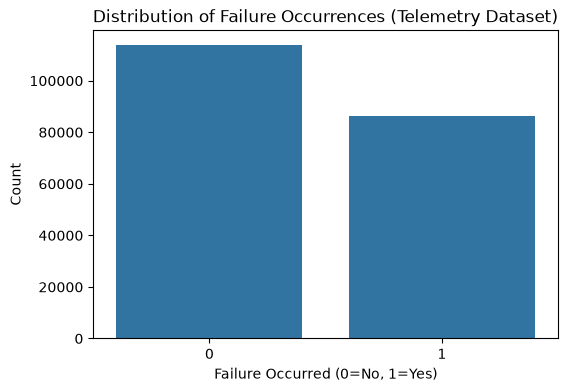

Failure Occurred Distribution (Telemetry Dataset):
failureOccurred
0    56.8895
1    43.1105
Name: proportion, dtype: float64


In [26]:
# Failure Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='failureOccurred', data=telemetry_final_cleaned_df)
plt.title('Distribution of Failure Occurrences (Telemetry Dataset)')
plt.xlabel('Failure Occurred (0=No, 1=Yes)')
plt.ylabel('Count')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_01.png', bbox_inches='tight', facecolor='white')
plt.show()

print("Failure Occurred Distribution (Telemetry Dataset):")
print(telemetry_final_cleaned_df['failureOccurred'].value_counts(normalize=True) * 100)

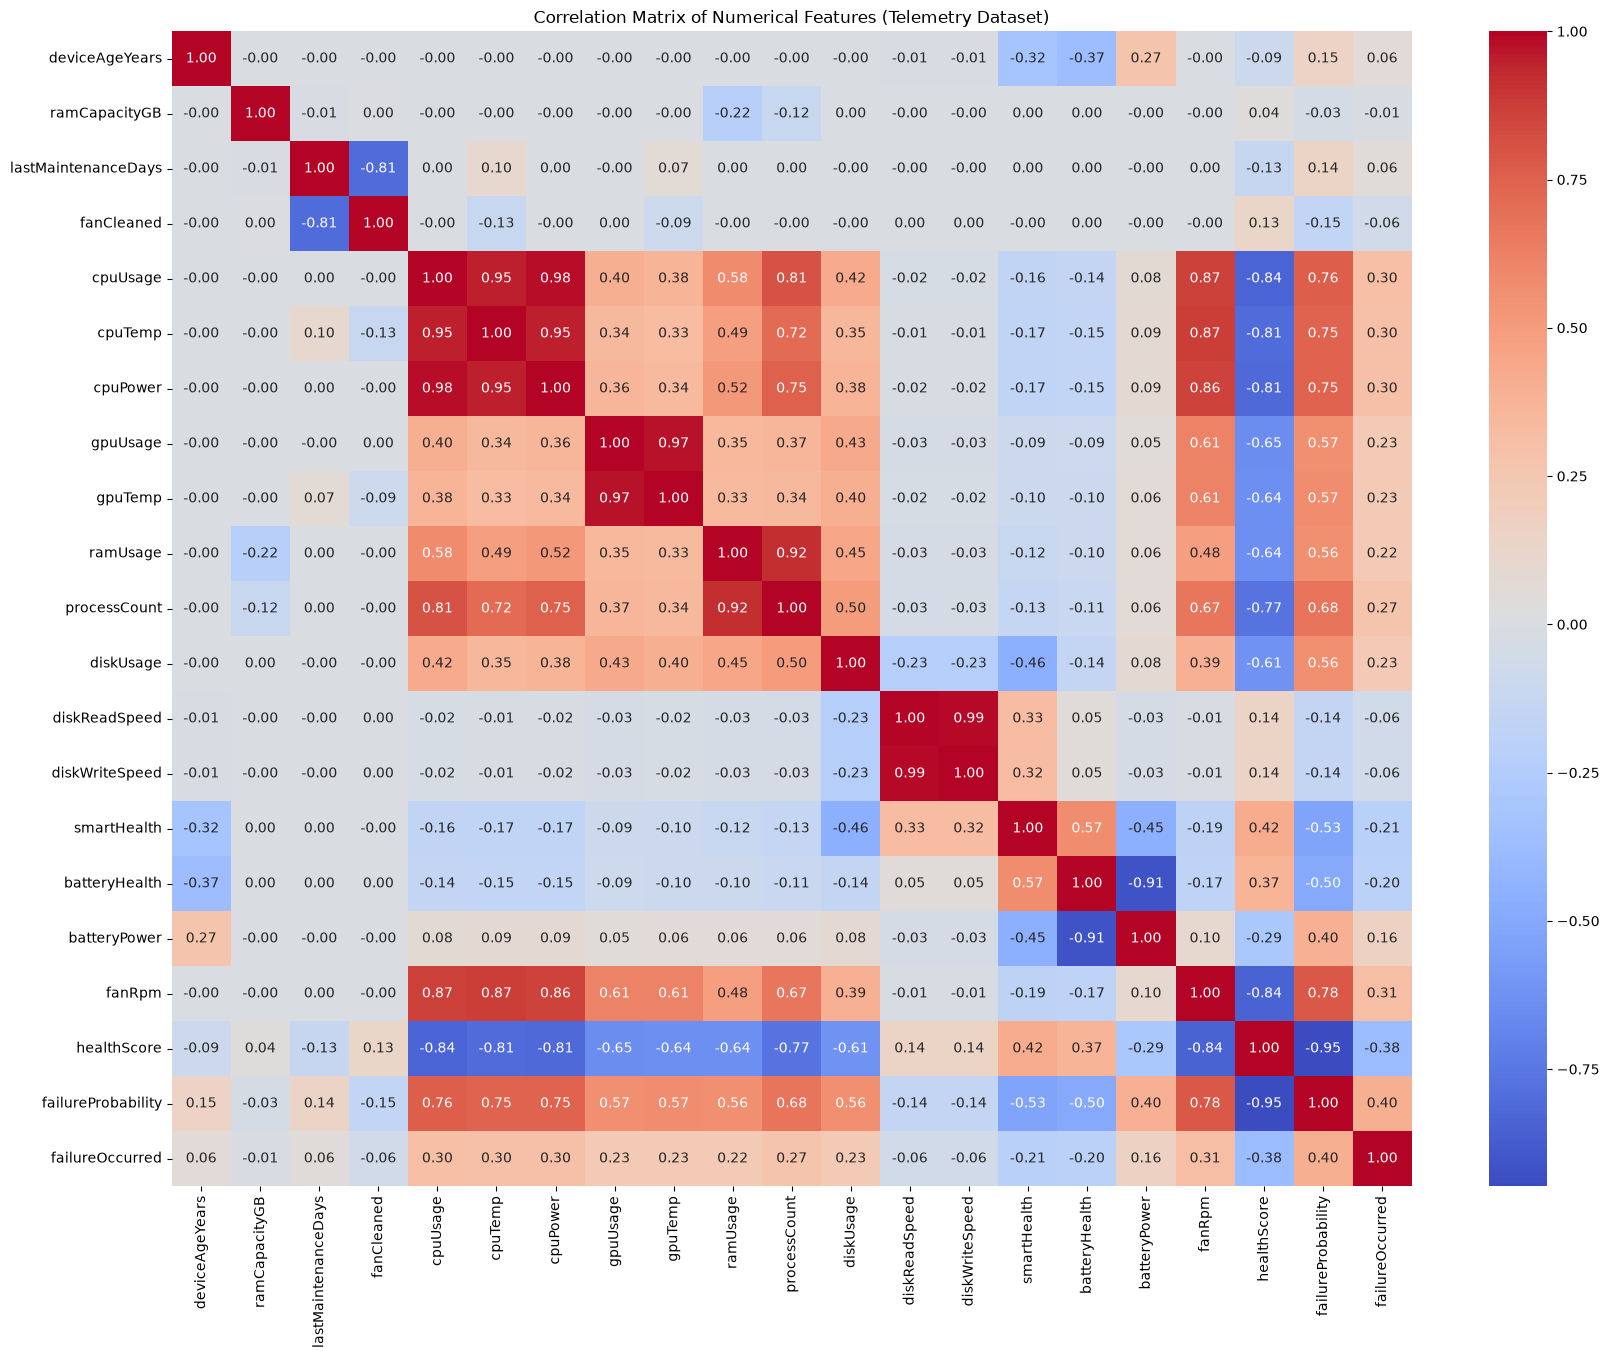

In [27]:
# Correlation Matrix
plt.figure(figsize=(20, 15))
sns.heatmap(telemetry_final_cleaned_df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features (Telemetry Dataset)')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_02.png', bbox_inches='tight', facecolor='white')
plt.show()

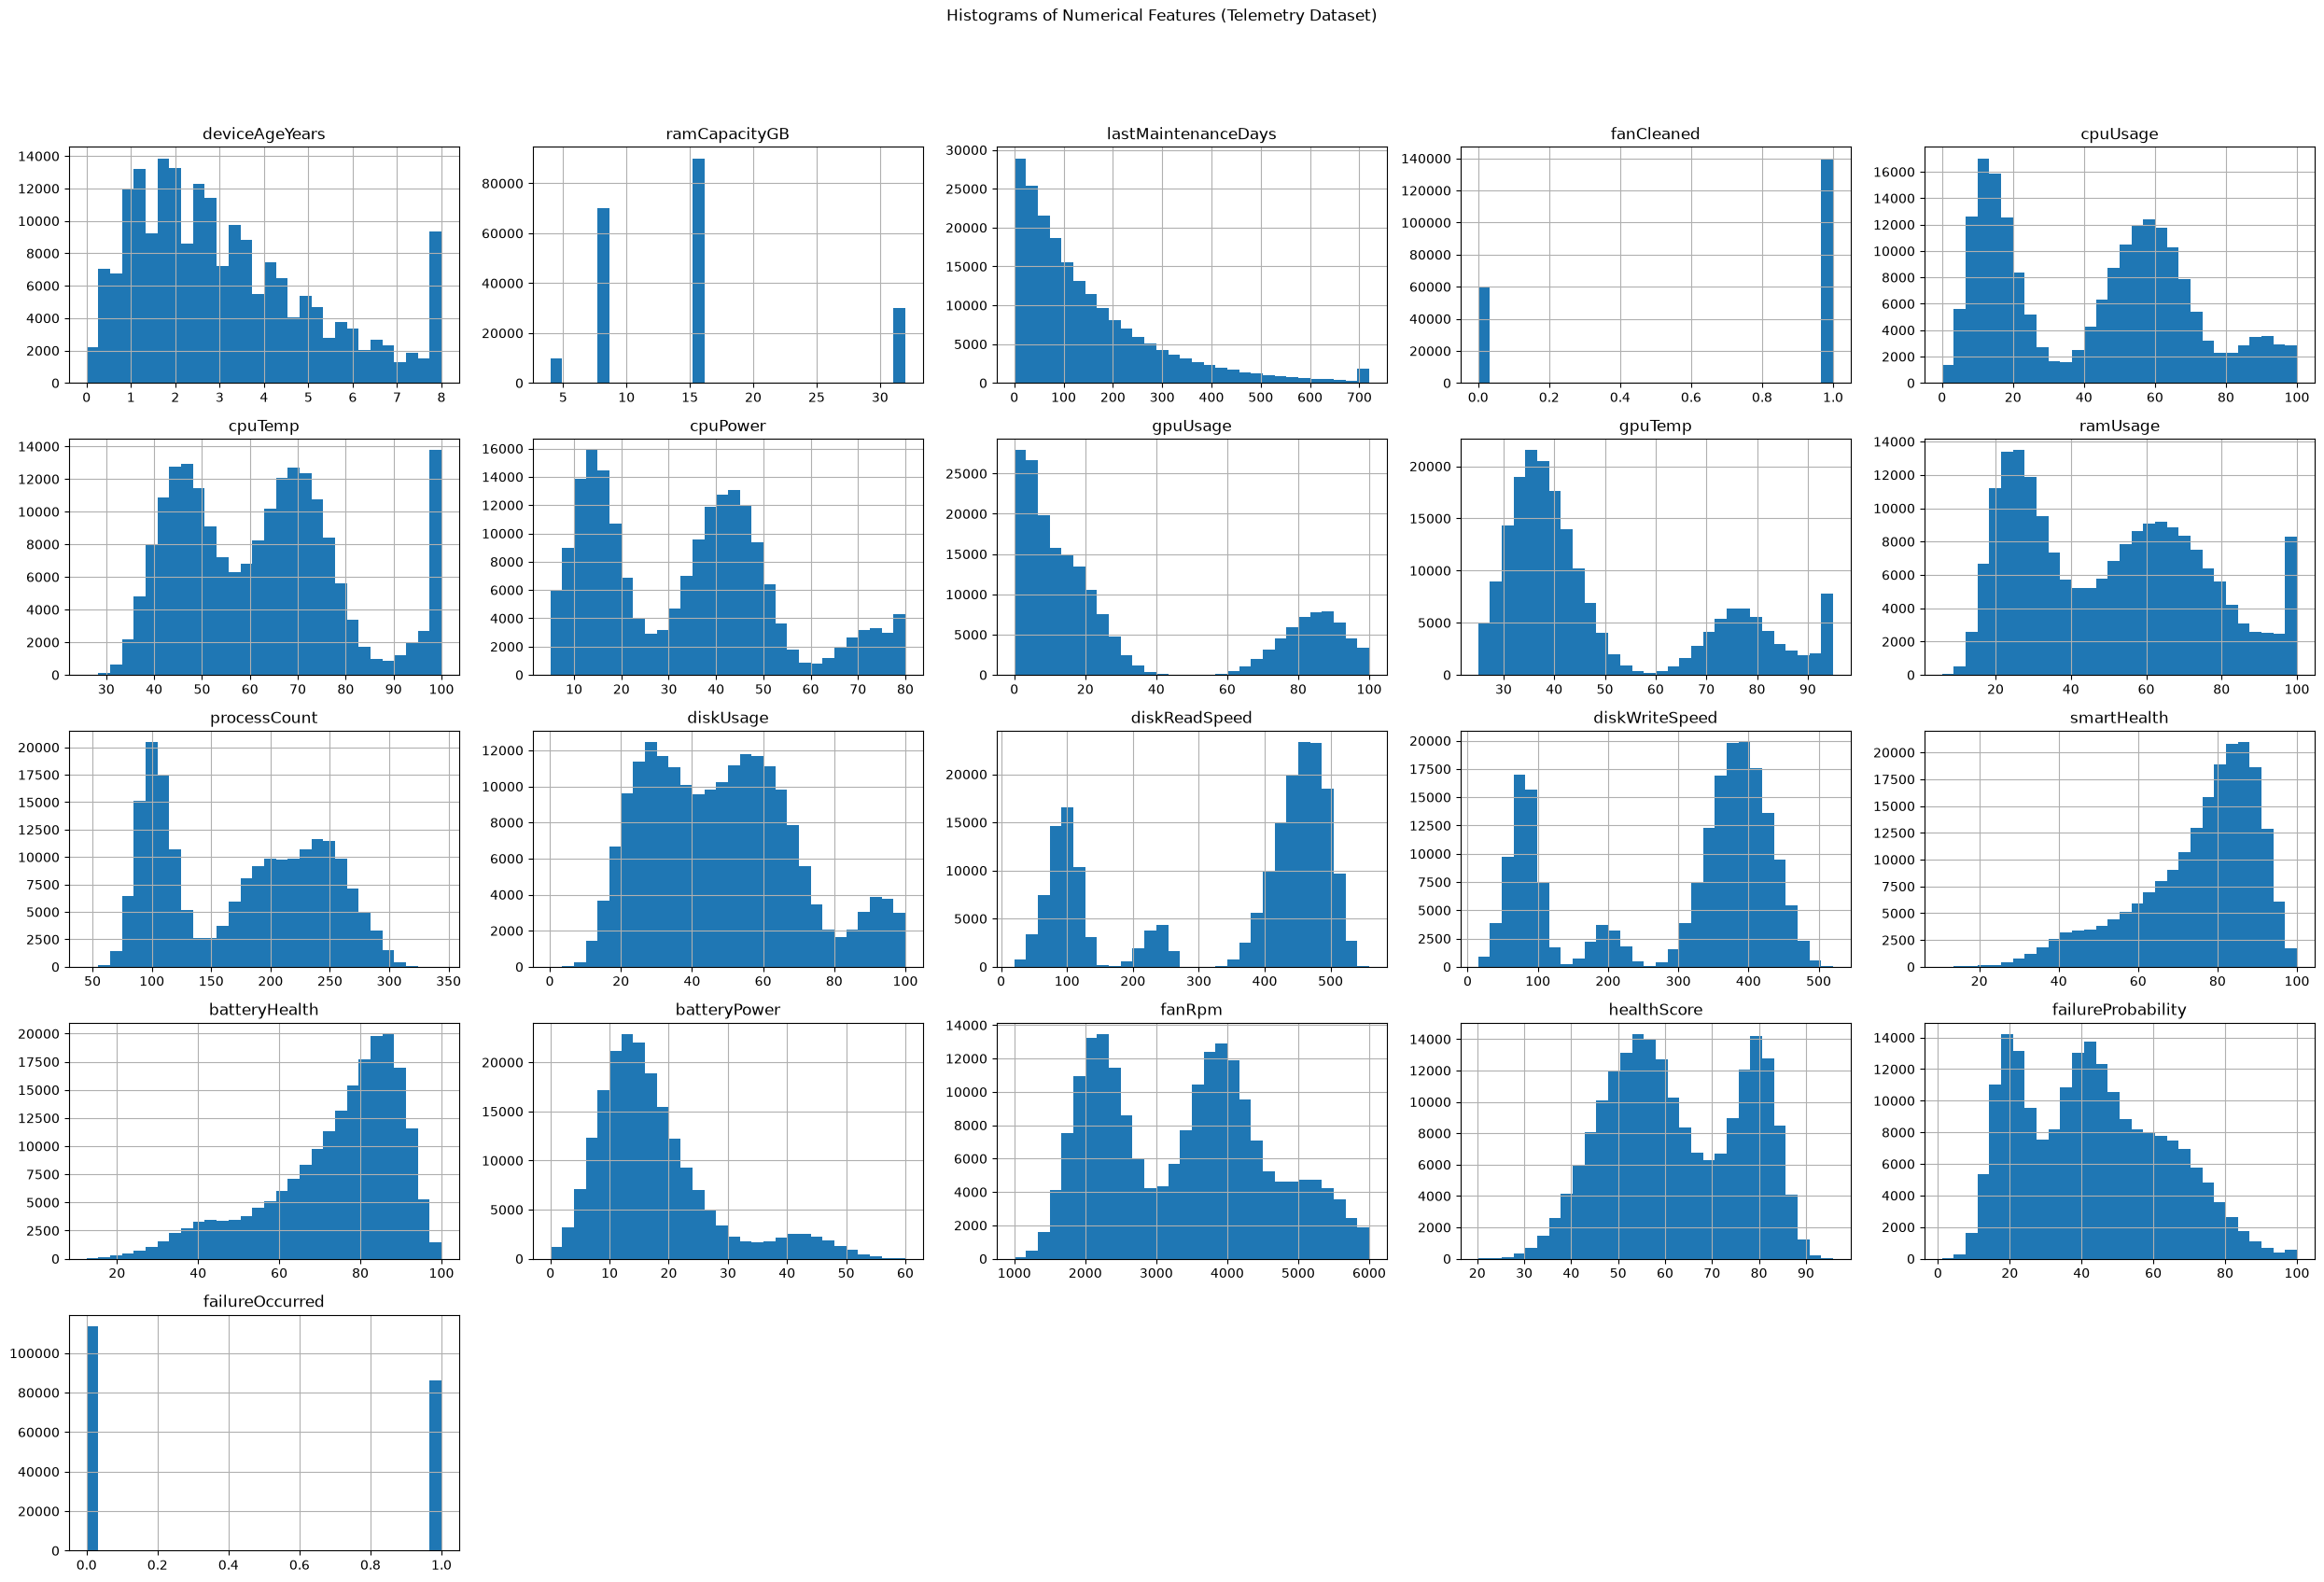

In [28]:
# Histograms for numerical features
telemetry_final_cleaned_df.select_dtypes(include=np.number).hist(bins=30, figsize=(25, 20), layout=(6, 5))
plt.suptitle('Histograms of Numerical Features (Telemetry Dataset)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_03.png', bbox_inches='tight', facecolor='white')
plt.show()

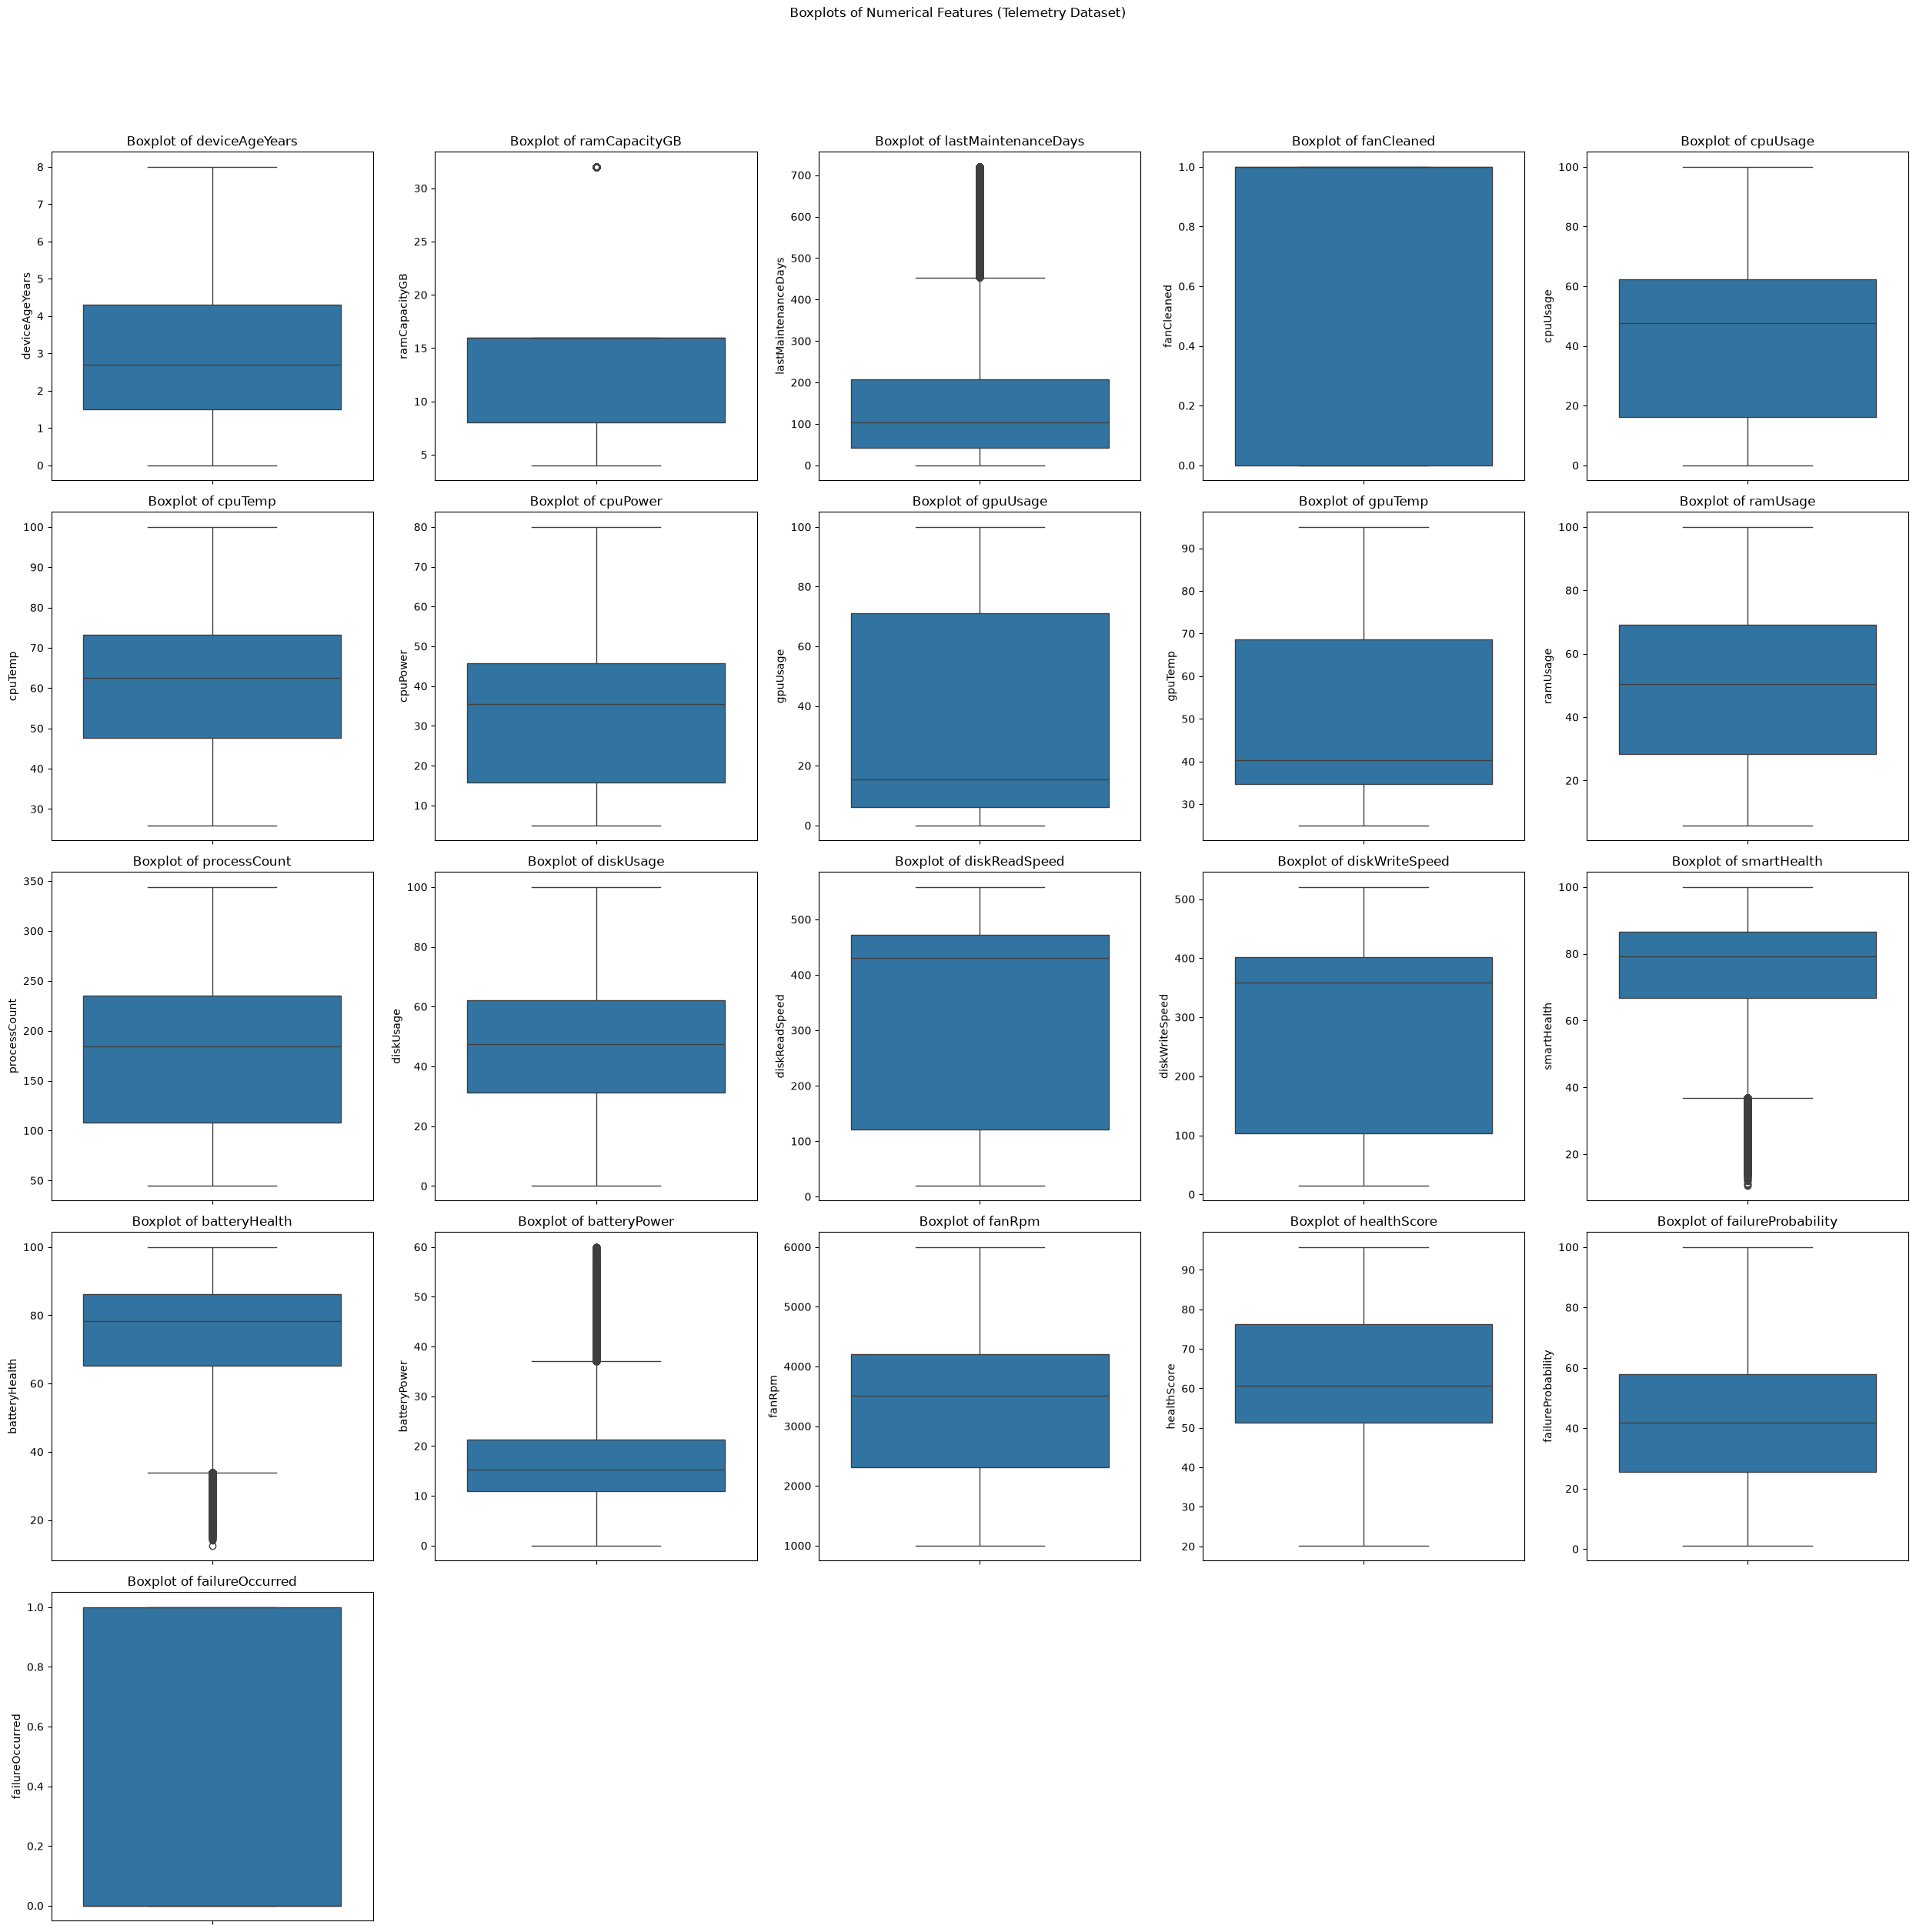

In [29]:
# Boxplots for numerical features to visualize outliers and distributions
plt.figure(figsize=(25, 30))
for i, col in enumerate(telemetry_final_cleaned_df.select_dtypes(include=np.number).columns):
    plt.subplot(6, 5, i + 1)
    sns.boxplot(y=telemetry_final_cleaned_df[col])
    plt.title(f'Boxplot of {col}')
plt.suptitle('Boxplots of Numerical Features (Telemetry Dataset)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_04.png', bbox_inches='tight', facecolor='white')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_20836\450912667.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='osVersion', data=telemetry_final_cleaned_df, palette='viridis')


C:\Users\HP\AppData\Local\Temp\ipykernel_20836\450912667.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='usageType', data=telemetry_final_cleaned_df, palette='magma')


C:\Users\HP\AppData\Local\Temp\ipykernel_20836\450912667.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diskType', data=telemetry_final_cleaned_df, palette='cividis')


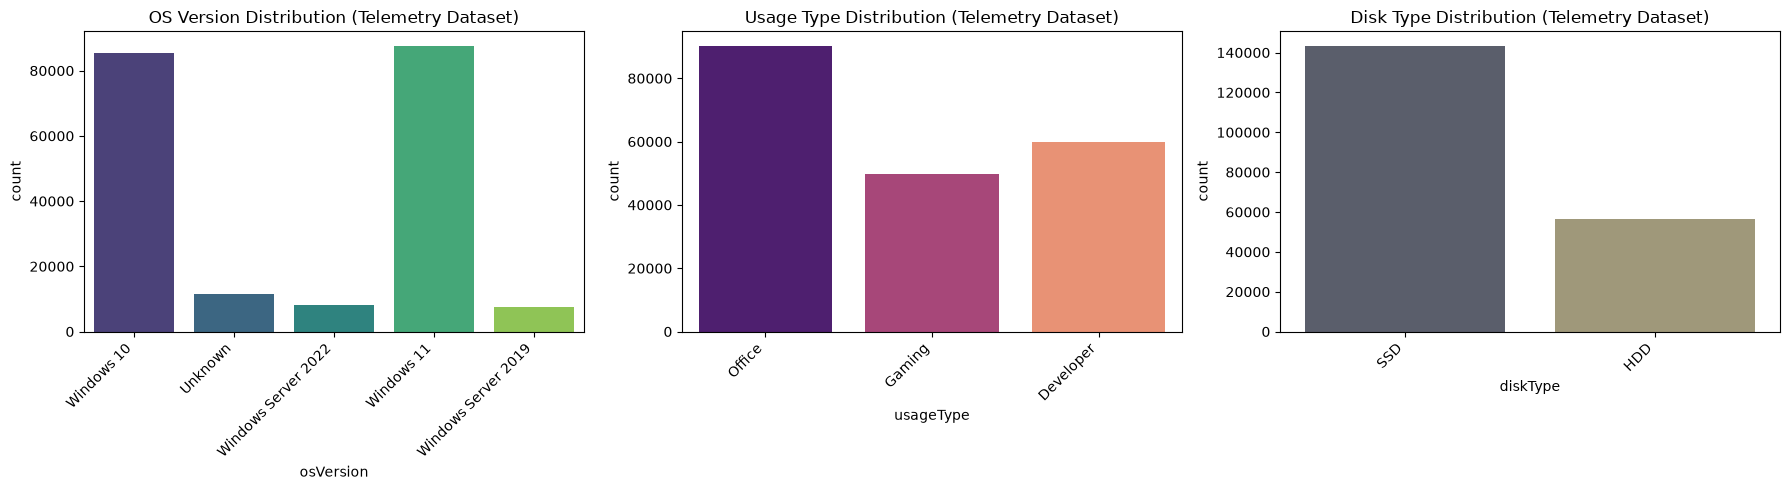

C:\Users\HP\AppData\Local\Temp\ipykernel_20836\450912667.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fanCleaned', data=telemetry_final_cleaned_df, palette='plasma')


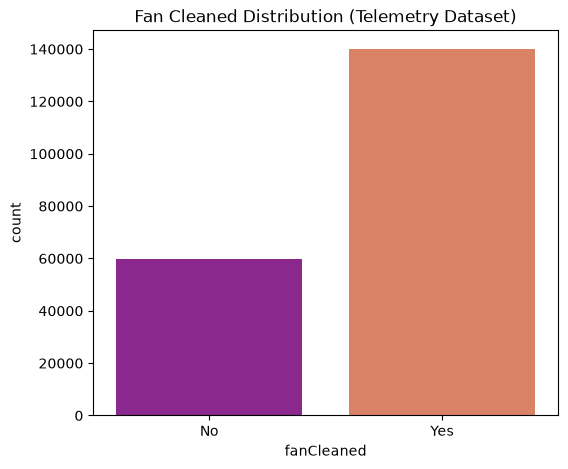

In [30]:
# Feature Distributions for Categorical Features
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='osVersion', data=telemetry_final_cleaned_df, palette='viridis')
plt.title('OS Version Distribution (Telemetry Dataset)')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.countplot(x='usageType', data=telemetry_final_cleaned_df, palette='magma')
plt.title('Usage Type Distribution (Telemetry Dataset)')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.countplot(x='diskType', data=telemetry_final_cleaned_df, palette='cividis')
plt.title('Disk Type Distribution (Telemetry Dataset)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_05.png', bbox_inches='tight', facecolor='white')
plt.show()

plt.figure(figsize=(6, 5))
sns.countplot(x='fanCleaned', data=telemetry_final_cleaned_df, palette='plasma')
plt.title('Fan Cleaned Distribution (Telemetry Dataset)')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], rotation=0)
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_06.png', bbox_inches='tight', facecolor='white')
plt.show()


Class Imbalance Analysis for 'failureOccurred' (Telemetry Dataset):
failureOccurred
0    113779
1     86221
Name: count, dtype: int64
Class 0 (No Failure): 56.89%
Class 1 (Failure): 43.11%


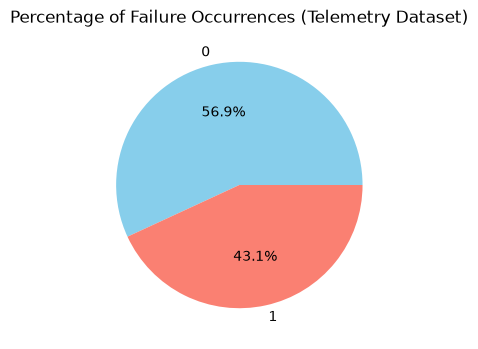

In [31]:
# Class Imbalance Analysis (already shown in Failure Distribution, but reiterating for clarity)
class_counts = telemetry_final_cleaned_df['failureOccurred'].value_counts()
print("\nClass Imbalance Analysis for 'failureOccurred' (Telemetry Dataset):")
print(class_counts)
print(f"Class 0 (No Failure): {class_counts[0] / len(telemetry_final_cleaned_df) * 100:.2f}%")
print(f"Class 1 (Failure): {class_counts[1] / len(telemetry_final_cleaned_df) * 100:.2f}%")

# A more visual representation of class imbalance
plt.figure(figsize=(6, 4))
class_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Percentage of Failure Occurrences (Telemetry Dataset)')
plt.ylabel('') # Hide the default 'failureOccurred' label
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_07.png', bbox_inches='tight', facecolor='white')
plt.show()

## STEP 3: EDA - AI4I Predictive Maintenance Dataset

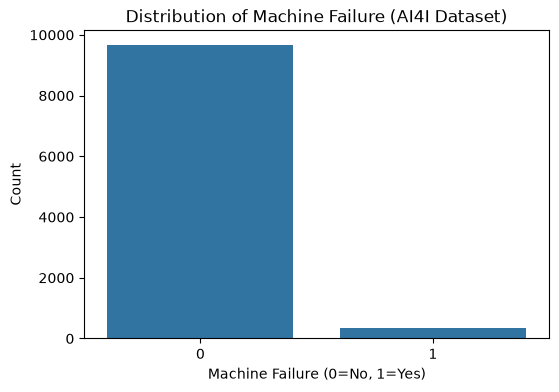

Machine Failure Distribution (AI4I Dataset):
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [32]:
# Failure Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Machine failure', data=ai4i_final_cleaned_df)
plt.title('Distribution of Machine Failure (AI4I Dataset)')
plt.xlabel('Machine Failure (0=No, 1=Yes)')
plt.ylabel('Count')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_08.png', bbox_inches='tight', facecolor='white')
plt.show()

print("Machine Failure Distribution (AI4I Dataset):")
print(ai4i_final_cleaned_df['Machine failure'].value_counts(normalize=True) * 100)

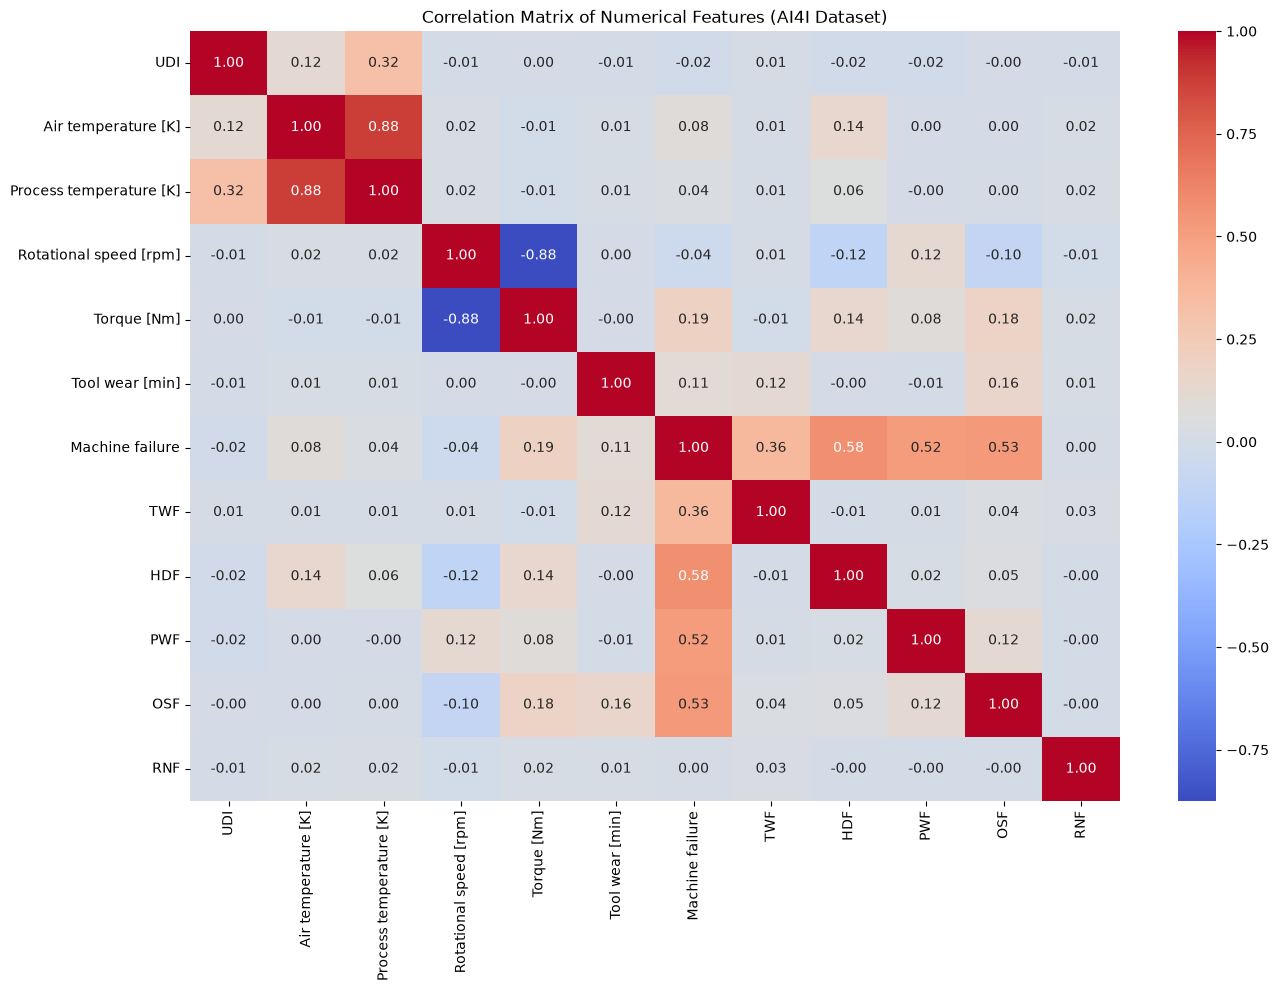

In [33]:
# Correlation Matrix
plt.figure(figsize=(15, 10))
sns.heatmap(ai4i_final_cleaned_df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features (AI4I Dataset)')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_09.png', bbox_inches='tight', facecolor='white')
plt.show()

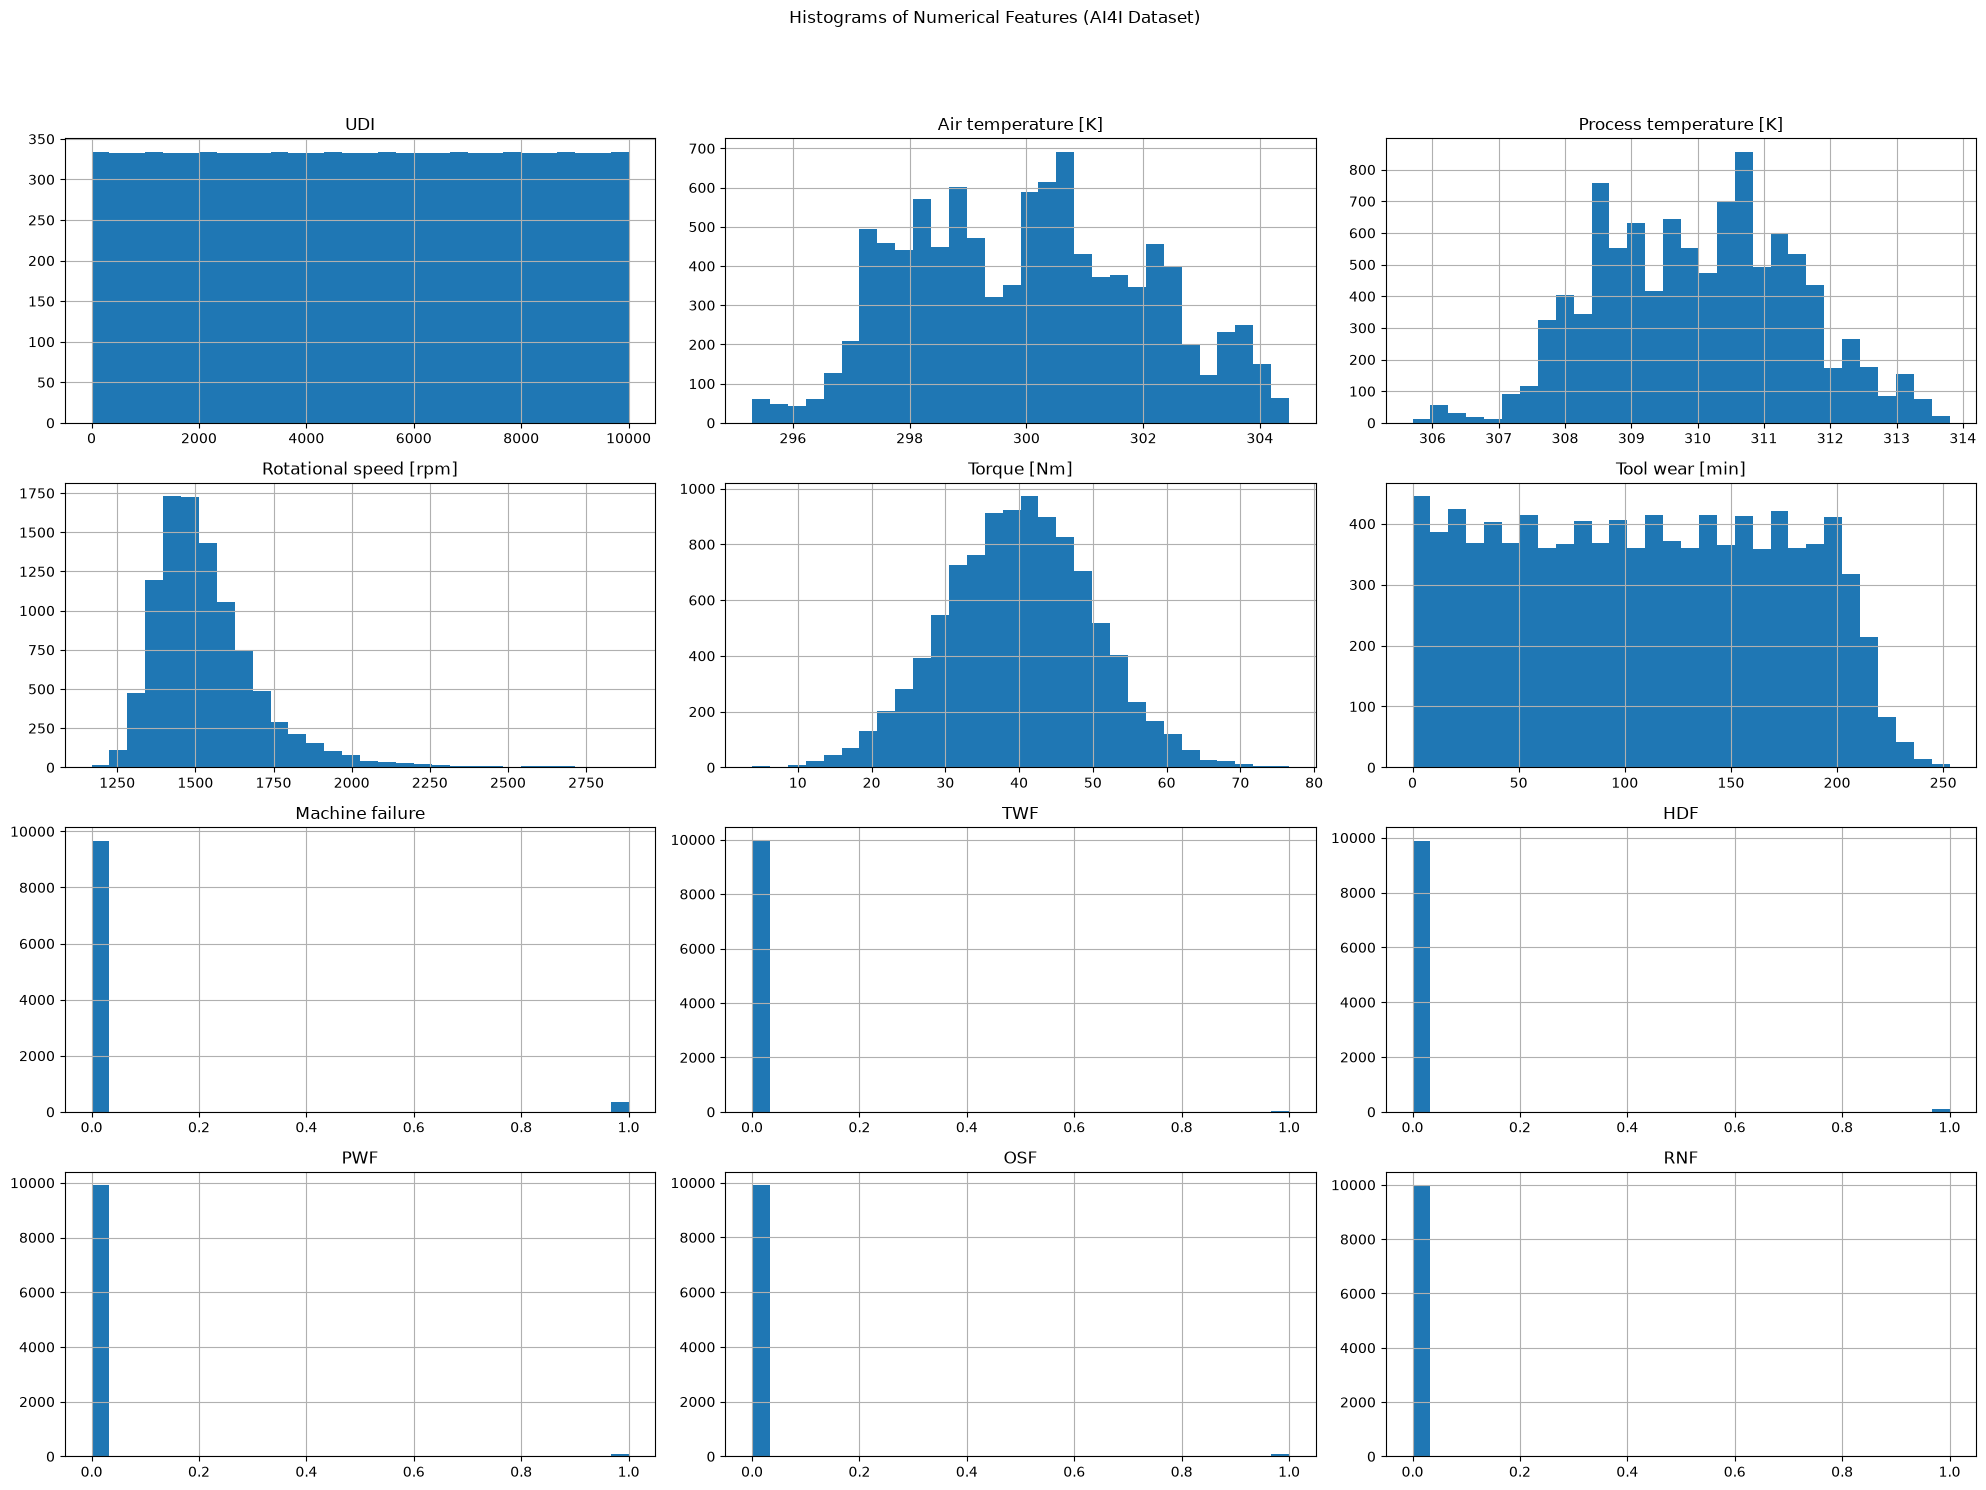

In [34]:
# Histograms for numerical features
ai4i_final_cleaned_df.select_dtypes(include=np.number).hist(bins=30, figsize=(20, 15), layout=(4, 3))
plt.suptitle('Histograms of Numerical Features (AI4I Dataset)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_10.png', bbox_inches='tight', facecolor='white')
plt.show()

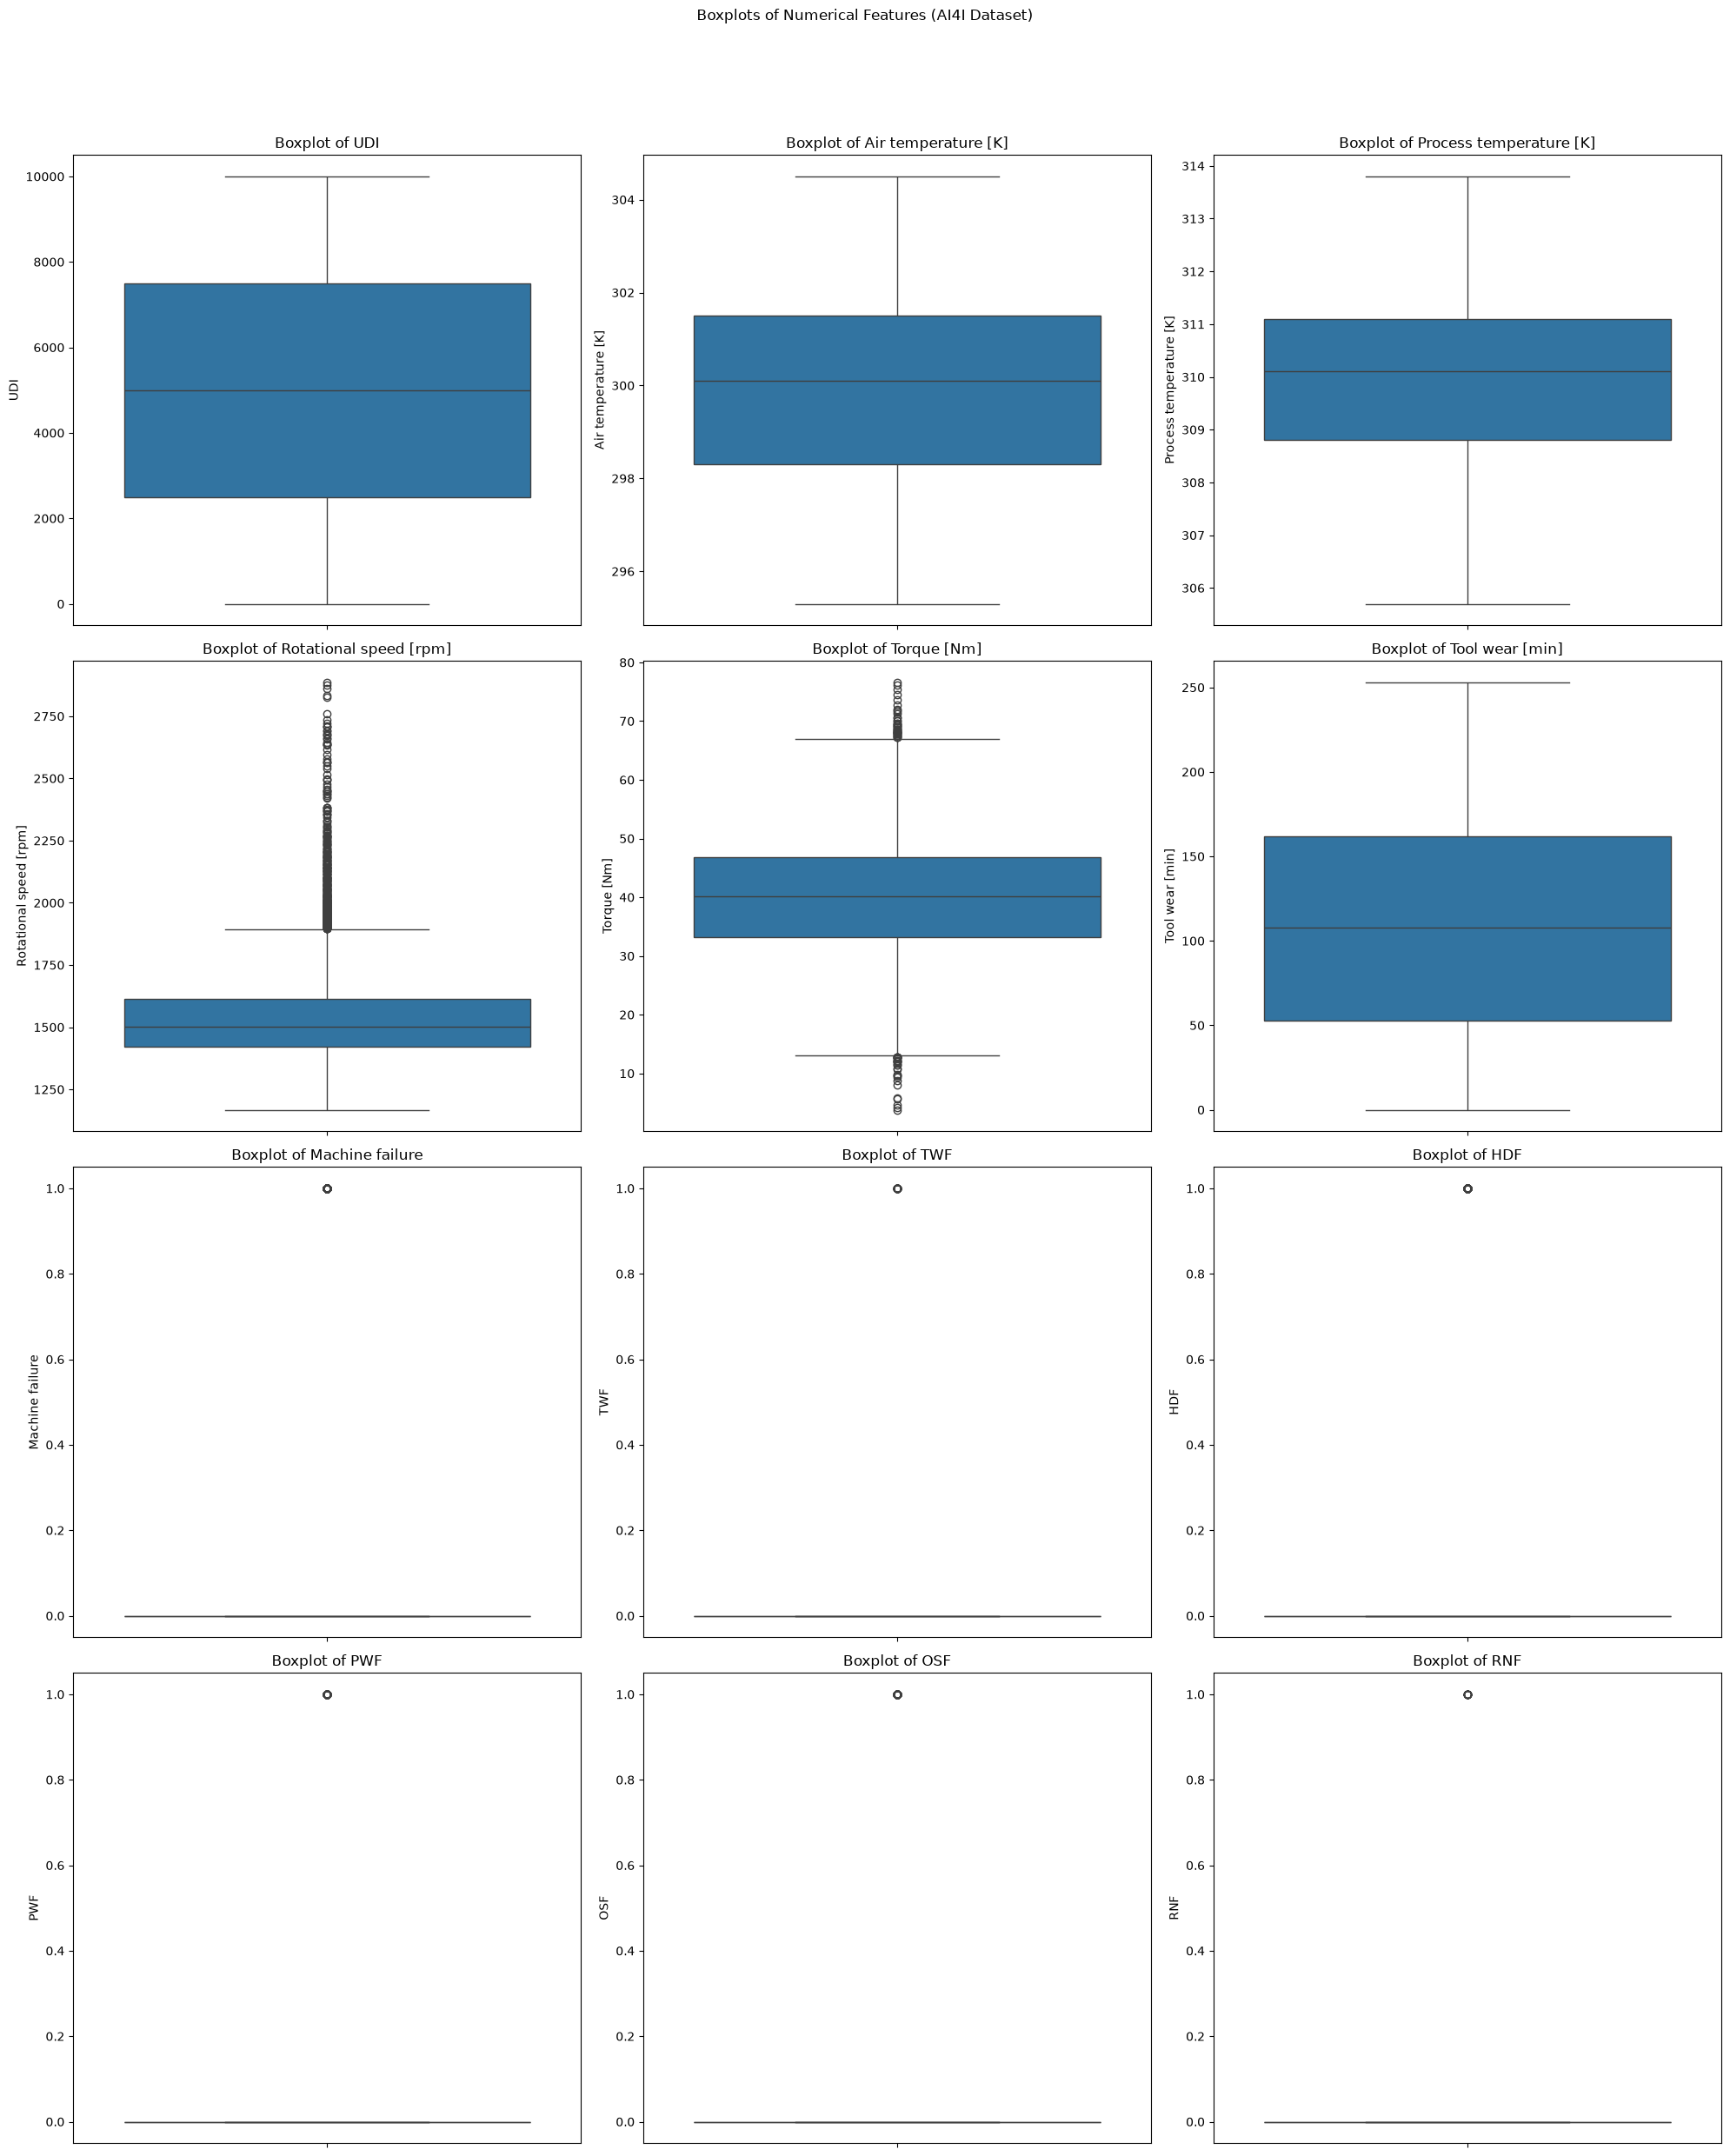

In [35]:
# Boxplots for numerical features to visualize outliers and distributions
plt.figure(figsize=(20, 25))
for i, col in enumerate(ai4i_final_cleaned_df.select_dtypes(include=np.number).columns):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=ai4i_final_cleaned_df[col])
    plt.title(f'Boxplot of {col}')
plt.suptitle('Boxplots of Numerical Features (AI4I Dataset)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_11.png', bbox_inches='tight', facecolor='white')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_20836\4178619266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=ai4i_final_cleaned_df, palette='viridis')


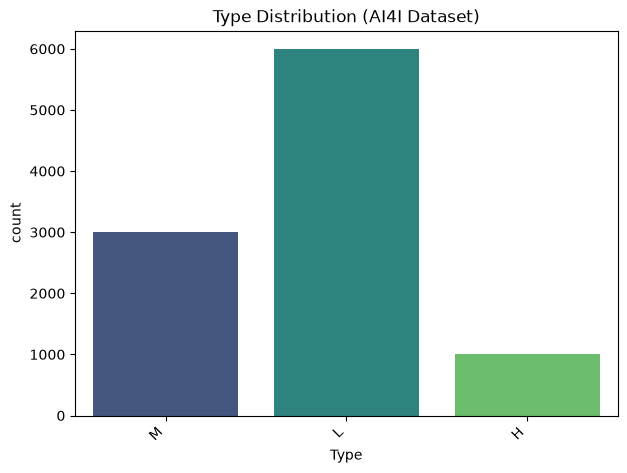

In [36]:
# Feature Distribution for Categorical Feature 'Type'
plt.figure(figsize=(7, 5))
sns.countplot(x='Type', data=ai4i_final_cleaned_df, palette='viridis')
plt.title('Type Distribution (AI4I Dataset)')
plt.xticks(rotation=45, ha='right')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_12.png', bbox_inches='tight', facecolor='white')
plt.show()


Class Imbalance Analysis for 'Machine failure' (AI4I Dataset):
Machine failure
0    9661
1     339
Name: count, dtype: int64
Class 0 (No Failure): 96.61%
Class 1 (Failure): 3.39%


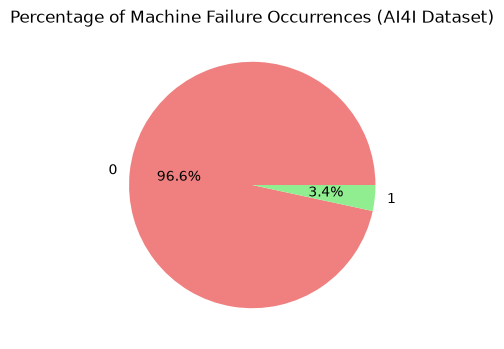

In [37]:
# Class Imbalance Analysis
class_counts_ai4i = ai4i_final_cleaned_df['Machine failure'].value_counts()
print("\nClass Imbalance Analysis for 'Machine failure' (AI4I Dataset):")
print(class_counts_ai4i)
print(f"Class 0 (No Failure): {class_counts_ai4i[0] / len(ai4i_final_cleaned_df) * 100:.2f}%")
print(f"Class 1 (Failure): {class_counts_ai4i[1] / len(ai4i_final_cleaned_df) * 100:.2f}%")

# Visual representation of class imbalance
plt.figure(figsize=(6, 4))
class_counts_ai4i.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Percentage of Machine Failure Occurrences (AI4I Dataset)')
plt.ylabel('')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_13.png', bbox_inches='tight', facecolor='white')
plt.show()

## STEP 4: Feature Engineering - Telemetry Health Dataset

In [38]:
# Feature Engineering for Telemetry Health Dataset

# Create a copy to perform feature engineering
telemetry_fe_df = telemetry_final_cleaned_df.copy()

# 1. Time-based Features from 'timestamp'
# Extract year, month, day, day of week, hour. Timestamp might be important for trends.
telemetry_fe_df['hour'] = telemetry_fe_df['timestamp'].dt.hour
telemetry_fe_df['day_of_week'] = telemetry_fe_df['timestamp'].dt.dayofweek
telemetry_fe_df['month'] = telemetry_fe_df['timestamp'].dt.month
telemetry_fe_df['year'] = telemetry_fe_df['timestamp'].dt.year

# 2. Interaction Features (Example: CPU/GPU Load Ratio)
# These are examples, specific interactions would be guided by domain knowledge or further EDA
telemetry_fe_df['cpu_gpu_load_ratio'] = telemetry_fe_df['cpuUsage'] / (telemetry_fe_df['gpuUsage'] + 1e-6) # Add small epsilon to avoid division by zero
telemetry_fe_df['temp_power_ratio_cpu'] = telemetry_fe_df['cpuTemp'] / (telemetry_fe_df['cpuPower'] + 1e-6)
telemetry_fe_df['disk_activity_score'] = telemetry_fe_df['diskReadSpeed'] + telemetry_fe_df['diskWriteSpeed']

# 3. Polynomial Features (Example: for non-linear relationships)
# Not adding aggressively at this stage, but noted as a technique. For instance, (deviceAgeYears)^2

# 4. One-Hot Encoding for Categorical Features
# Columns: 'osVersion', 'usageType', 'diskType', 'riskLevel', 'rootCause'
# 'fanCleaned' is already numerical (0/1)

# Drop output/target columns to prevent data leakage
leakage_cols = ['healthScore', 'failureProbability', 'riskLevel', 'rootCause']
telemetry_fe_df.drop(columns=[col for col in leakage_cols if col in telemetry_fe_df.columns], inplace=True)

categorical_cols_telemetry = ['osVersion', 'usageType', 'diskType']
telemetry_fe_df = pd.get_dummies(telemetry_fe_df, columns=categorical_cols_telemetry, drop_first=True)

# Drop original timestamp column as features have been extracted
telemetry_fe_df.drop('timestamp', axis=1, inplace=True)

print("Telemetry Health Dataset - Features Engineered. New shape:")
print(telemetry_fe_df.shape)
print("First 5 rows of engineered dataset:")
display(telemetry_fe_df.head())

Telemetry Health Dataset - Features Engineered. New shape:
(200000, 33)
First 5 rows of engineered dataset:


,deviceAgeYears,ramCapacityGB,lastMaintenanceDays,fanCleaned,cpuUsage,cpuTemp,cpuPower,gpuUsage,gpuTemp,ramUsage,...,cpu_gpu_load_ratio,temp_power_ratio_cpu,disk_activity_score,osVersion_Windows 10,osVersion_Windows 11,osVersion_Windows Server 2019,osVersion_Windows Server 2022,usageType_Gaming,usageType_Office,diskType_SSD
0,3.8,16,236,0,19.08,54.59,15.00,14.67,43.45,28.34,...,1.300613,3.639333,733.1,True,False,False,False,False,True,True
1,2.4,16,720,0,45.89,61.79,33.15,65.57,67.36,56.90,...,0.699863,1.863952,932.4,True,False,False,False,True,False,True
2,2.2,16,142,1,11.24,44.98,12.78,4.23,32.03,25.71,...,2.657210,3.519562,377.1,False,False,False,False,False,True,True
3,2.2,32,218,0,58.07,76.79,47.13,25.64,52.86,60.96,...,2.264821,1.629323,144.2,False,False,False,True,False,False,False
4,7.4,16,24,1,18.21,47.22,16.62,2.40,32.36,14.51,...,7.587497,2.841155,851.6,True,False,False,False,False,True,True


## STEP 4: Feature Engineering - AI4I Predictive Maintenance Dataset

In [39]:
# Feature Engineering for AI4I Predictive Maintenance Dataset

# Create a copy to perform feature engineering
ai4i_fe_df = ai4i_final_cleaned_df.copy()

# 1. Temperature Difference
ai4i_fe_df['temp_diff'] = ai4i_fe_df['Process temperature [K]'] - ai4i_fe_df['Air temperature [K]']

# 2. Power Load Feature
# Assuming torque and rotational speed can indicate power or load
ai4i_fe_df['power_load'] = ai4i_fe_df['Rotational speed [rpm]'] * ai4i_fe_df['Torque [Nm]']

# 3. Tool Wear Rate
# This might need a time component, but for now, we can consider direct 'Tool wear [min]'
# or its interaction with other factors. For simplicity, just its value for now.

# 4. One-Hot Encoding for Categorical Features
# Column: 'Type'
categorical_cols_ai4i = ['Type']
ai4i_fe_df = pd.get_dummies(ai4i_fe_df, columns=categorical_cols_ai4i, drop_first=True)

# Drop UDI as it's an identifier and not a feature for prediction
ai4i_fe_df.drop('UDI', axis=1, inplace=True)

print("AI4I Predictive Maintenance Dataset - Features Engineered. New shape:")
print(ai4i_fe_df.shape)
print("First 5 rows of engineered dataset:")
display(ai4i_fe_df.head())

AI4I Predictive Maintenance Dataset - Features Engineered. New shape:
(10000, 15)
First 5 rows of engineered dataset:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_diff,power_load,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,True,False


## STEP 5: Feature Selection - Telemetry Health Dataset

In [40]:
# Feature Selection for Telemetry Health Dataset

# Create a copy to perform feature selection
telemetry_fs_df = telemetry_fe_df.copy()

# Define target variable
X_telemetry = telemetry_fs_df.drop('failureOccurred', axis=1)
y_telemetry = telemetry_fs_df['failureOccurred']

# Separate numerical and categorical features for selection strategies if needed
numerical_features_telemetry = X_telemetry.select_dtypes(include=np.number).columns.tolist()
categorical_features_telemetry = X_telemetry.select_dtypes(include='object').columns.tolist()

# --- Strategy 1: Correlation with Target (for numerical features) ---
print("\n--- Telemetry: Features by Correlation with 'failureOccurred' ---")
correlations = telemetry_fs_df.corr(numeric_only=True)['failureOccurred'].abs().sort_values(ascending=False)
print(correlations)

# We will keep features with correlation above a certain threshold (e.g., 0.05) or top N features
# For now, let's just report and consider dropping highly correlated features with each other later if multicollinearity becomes an issue

# --- Strategy 2: Feature Importance from a simple model (e.g., RandomForestClassifier) ---
# This will also handle one-hot encoded features directly
from sklearn.ensemble import RandomForestClassifier

# Temporarily drop columns that are not suitable for direct RF (e.g., very high cardinality object columns if any remained)
# In our case, all categorical columns were one-hot encoded or dropped, so X_telemetry is ready.

# Initialize and train a RandomForestClassifier
rf_model_telemetry = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_telemetry.fit(X_telemetry, y_telemetry)

# Get feature importances
feature_importances_telemetry = pd.Series(rf_model_telemetry.feature_importances_, index=X_telemetry.columns)
print("\n--- Telemetry: Top Feature Importances from RandomForest ---")
print(feature_importances_telemetry.sort_values(ascending=False).head(20)) # Display top 20

# --- Strategy 3: Variance Threshold (for low variance features) ---
from sklearn.feature_selection import VarianceThreshold

# Remove features with low variance (e.g., less than 80% of samples having the same value)
selector_telemetry = VarianceThreshold(threshold=0.01 * (1 - 0.01)) # Threshold for binary features (p*(1-p))
selector_telemetry.fit(X_telemetry)

# Get the features that were kept
features_kept_variance_telemetry = X_telemetry.columns[selector_telemetry.get_support()]
features_removed_variance_telemetry = X_telemetry.columns[~selector_telemetry.get_support()]

print(f"\n--- Telemetry: Features removed by Variance Threshold ({len(features_removed_variance_telemetry)} features) ---")
if not features_removed_variance_telemetry.empty:
    print(features_removed_variance_telemetry.tolist())
else:
    print("No features removed by Variance Threshold.")

# For now, we are just performing analysis. The actual selection/dropping will be done in subsequent steps or after review.
# We will consider a combination of these methods to select the final features.
print(f"\nTelemetry Health Dataset - Shape before selection: {telemetry_fs_df.shape}")

# Store the feature importances for later use
telemetry_feature_importances = feature_importances_telemetry
telemetry_correlations = correlations


--- Telemetry: Features by Correlation with 'failureOccurred' ---


failureOccurred                  1.000000
fanRpm                           0.312796
cpuUsage                         0.303515
cpuTemp                          0.298959
cpuPower                         0.298045
processCount                     0.269716
usageType_Office                 0.266572
gpuTemp                          0.230201
gpuUsage                         0.227843
diskUsage                        0.225564
ramUsage                         0.224454
temp_power_ratio_cpu             0.223705
smartHealth                      0.213303
batteryHealth                    0.198295
usageType_Gaming                 0.179501
batteryPower                     0.158982
deviceAgeYears                   0.060105
fanCleaned                       0.059084
diskReadSpeed                    0.058764
disk_activity_score              0.058456
diskWriteSpeed                   0.057698
lastMaintenanceDays              0.055386
osVersion_Windows Server 2019    0.039693
osVersion_Windows Server 2022    0


--- Telemetry: Top Feature Importances from RandomForest ---
fanRpm                  0.062212
smartHealth             0.056104
cpuTemp                 0.053619
cpuUsage                0.053173
batteryHealth           0.052817
cpuPower                0.049539
processCount            0.049183
batteryPower            0.048099
temp_power_ratio_cpu    0.047539
diskUsage               0.046442
ramUsage                0.044864
gpuTemp                 0.044202
gpuUsage                0.042847
lastMaintenanceDays     0.041299
cpu_gpu_load_ratio      0.040352
diskReadSpeed           0.038599
diskWriteSpeed          0.038580
disk_activity_score     0.037515
deviceAgeYears          0.035446
hour                    0.027962
dtype: float64

--- Telemetry: Features removed by Variance Threshold (0 features) ---
No features removed by Variance Threshold.

Telemetry Health Dataset - Shape before selection: (200000, 33)


## STEP 5: Feature Selection - AI4I Predictive Maintenance Dataset

In [41]:
# Feature Selection for AI4I Predictive Maintenance Dataset

# Create a copy to perform feature selection
ai4i_fs_df = ai4i_fe_df.copy()

# Define target variable
X_ai4i = ai4i_fs_df.drop('Machine failure', axis=1)
y_ai4i = ai4i_fs_df['Machine failure']

# Separate numerical and categorical features for selection strategies if needed
numerical_features_ai4i = X_ai4i.select_dtypes(include=np.number).columns.tolist()
categorical_features_ai4i = X_ai4i.select_dtypes(include='object').columns.tolist() # Should be empty after one-hot encoding

# --- Strategy 1: Correlation with Target (for numerical features) ---
print("\n--- AI4I: Features by Correlation with 'Machine failure' ---")
correlations_ai4i = ai4i_fs_df.corr(numeric_only=True)['Machine failure'].abs().sort_values(ascending=False)
print(correlations_ai4i)

# --- Strategy 2: Feature Importance from a simple model (e.g., RandomForestClassifier) ---
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier
rf_model_ai4i = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_ai4i.fit(X_ai4i, y_ai4i)

# Get feature importances
feature_importances_ai4i = pd.Series(rf_model_ai4i.feature_importances_, index=X_ai4i.columns)
print("\n--- AI4I: Top Feature Importances from RandomForest ---")
print(feature_importances_ai4i.sort_values(ascending=False).head(20)) # Display top 20

# --- Strategy 3: Variance Threshold (for low variance features) ---
from sklearn.feature_selection import VarianceThreshold

# Remove features with low variance (e.g., less than 80% of samples having the same value)
selector_ai4i = VarianceThreshold(threshold=0.01 * (1 - 0.01)) # Threshold for binary features (p*(1-p))
selector_ai4i.fit(X_ai4i)

# Get the features that were kept
features_kept_variance_ai4i = X_ai4i.columns[selector_ai4i.get_support()]
features_removed_variance_ai4i = X_ai4i.columns[~selector_ai4i.get_support()]

print(f"\n--- AI4I: Features removed by Variance Threshold ({len(features_removed_variance_ai4i)} features) ---")
if not features_removed_variance_ai4i.empty:
    print(features_removed_variance_ai4i.tolist())
else:
    print("No features removed by Variance Threshold.")

# For now, we are just performing analysis. The actual selection/dropping will be done in subsequent steps or after review.
# We will consider a combination of these methods to select the final features.
print(f"\nAI4I Predictive Maintenance Dataset - Shape before selection: {ai4i_fs_df.shape}")

# Store the feature importances for later use
ai4i_feature_importances = feature_importances_ai4i
ai4i_correlations = correlations_ai4i


--- AI4I: Features by Correlation with 'Machine failure' ---
Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
power_load                 0.176039
temp_diff                  0.111676
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]     0.044188
Process temperature [K]    0.035946
Type_L                     0.035643
Type_M                     0.022432
RNF                        0.004516
Name: Machine failure, dtype: float64



--- AI4I: Top Feature Importances from RandomForest ---
HDF                        0.238898
OSF                        0.194797
PWF                        0.131225
TWF                        0.116269
power_load                 0.092840
Rotational speed [rpm]     0.060162
Torque [Nm]                0.059108
temp_diff                  0.044019
Tool wear [min]            0.035997
Air temperature [K]        0.012029
Process temperature [K]    0.009765
Type_L                     0.002745
Type_M                     0.002113
RNF                        0.000033
dtype: float64

--- AI4I: Features removed by Variance Threshold (4 features) ---
['TWF', 'PWF', 'OSF', 'RNF']

AI4I Predictive Maintenance Dataset - Shape before selection: (10000, 15)


## STEP 6: Train Test Split - Telemetry Health Dataset

In [42]:
# Train Test Split for Telemetry Health Dataset
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X_telemetry = telemetry_fe_df.drop('failureOccurred', axis=1)
y_telemetry = telemetry_fe_df['failureOccurred']

# Perform stratified train-test split
X_train_telemetry, X_test_telemetry, y_train_telemetry, y_test_telemetry = train_test_split(
    X_telemetry, y_telemetry, test_size=0.2, random_state=42, stratify=y_telemetry
)

print("Telemetry Health Dataset - Train Test Split Summary:")
print(f"X_train_telemetry shape: {X_train_telemetry.shape}")
print(f"X_test_telemetry shape: {X_test_telemetry.shape}")
print(f"y_train_telemetry shape: {y_train_telemetry.shape}")
print(f"y_test_telemetry shape: {y_test_telemetry.shape}")

print("\nTelemetry - Target distribution in original dataset:")
print(y_telemetry.value_counts(normalize=True) * 100)
print("\nTelemetry - Target distribution in training set:")
print(y_train_telemetry.value_counts(normalize=True) * 100)
print("\nTelemetry - Target distribution in testing set:")
print(y_test_telemetry.value_counts(normalize=True) * 100)

Telemetry Health Dataset - Train Test Split Summary:
X_train_telemetry shape: (160000, 32)
X_test_telemetry shape: (40000, 32)
y_train_telemetry shape: (160000,)
y_test_telemetry shape: (40000,)

Telemetry - Target distribution in original dataset:
failureOccurred
0    56.8895
1    43.1105
Name: proportion, dtype: float64

Telemetry - Target distribution in training set:
failureOccurred
0    56.889375
1    43.110625
Name: proportion, dtype: float64

Telemetry - Target distribution in testing set:
failureOccurred
0    56.89
1    43.11
Name: proportion, dtype: float64


## STEP 6: Train Test Split - AI4I Predictive Maintenance Dataset

In [43]:
# Train Test Split for AI4I Predictive Maintenance Dataset
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X_ai4i = ai4i_fe_df.drop('Machine failure', axis=1)
y_ai4i = ai4i_fe_df['Machine failure']

# Sanitize feature names for XGBoost compatibility immediately after X_ai4i is defined
# This ensures that all subsequent operations and saved artifacts use sanitized names
X_ai4i.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in X_ai4i.columns]

# Perform stratified train-test split
X_train_ai4i, X_test_ai4i, y_train_ai4i, y_test_ai4i = train_test_split(
    X_ai4i, y_ai4i, test_size=0.2, random_state=42, stratify=y_ai4i
)

print("AI4I Predictive Maintenance Dataset - Train Test Split Summary:")
print(f"X_train_ai4i shape: {X_train_ai4i.shape}")
print(f"X_test_ai4i shape: {X_test_ai4i.shape}")
print(f"y_train_ai4i shape: {y_train_ai4i.shape}")
print(f"y_test_ai4i shape: {y_test_ai4i.shape}")

print("\nAI4I - Target distribution in original dataset:")
print(y_ai4i.value_counts(normalize=True) * 100)
print("\nAI4I - Target distribution in training set:")
print(y_train_ai4i.value_counts(normalize=True) * 100)
print("\nAI4I - Target distribution in testing set:")
print(y_test_ai4i.value_counts(normalize=True) * 100)

AI4I Predictive Maintenance Dataset - Train Test Split Summary:
X_train_ai4i shape: (8000, 14)
X_test_ai4i shape: (2000, 14)
y_train_ai4i shape: (8000,)
y_test_ai4i shape: (2000,)

AI4I - Target distribution in original dataset:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

AI4I - Target distribution in training set:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

AI4I - Target distribution in testing set:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## STEP 7: Class Imbalance Handling - Telemetry Health Dataset

In [44]:
# Class Imbalance Handling for Telemetry Health Dataset

from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original Telemetry dataset target distribution:")
print(Counter(y_train_telemetry))

# Given that the Telemetry dataset is relatively balanced (56.83% No Failure, 43.17% Failure),
# explicit oversampling or undersampling might not be strictly necessary, but we can apply SMOTE
# to slightly balance it if desired or to demonstrate the technique.
# For this phase, we'll apply a mild oversampling to ensure both classes have a similar representation.

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_telemetry_resampled, y_train_telemetry_resampled = smote.fit_resample(X_train_telemetry, y_train_telemetry)

print("\nTelemetry dataset target distribution after SMOTE (minority oversampled):")
print(Counter(y_train_telemetry_resampled))

print(f"Telemetry Training set shape before SMOTE: {X_train_telemetry.shape}")
print(f"Telemetry Training set shape after SMOTE: {X_train_telemetry_resampled.shape}")

Original Telemetry dataset target distribution:
Counter({0: 91023, 1: 68977})



Telemetry dataset target distribution after SMOTE (minority oversampled):
Counter({1: 91023, 0: 91023})
Telemetry Training set shape before SMOTE: (160000, 32)
Telemetry Training set shape after SMOTE: (182046, 32)


## STEP 7: Class Imbalance Handling - AI4I Predictive Maintenance Dataset

In [45]:
# Class Imbalance Handling for AI4I Predictive Maintenance Dataset

from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original AI4I dataset target distribution:")
print(Counter(y_train_ai4i))

# The AI4I dataset has a significant class imbalance (96.61% No Failure, 3.39% Failure).
# SMOTE (Synthetic Minority Over-sampling Technique) is a good strategy to handle this.
# We will oversample the minority class ('1' for machine failure) to make its count closer to the majority class.

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_ai4i_resampled, y_train_ai4i_resampled = smote.fit_resample(X_train_ai4i, y_train_ai4i)

print("\nAI4I dataset target distribution after SMOTE (minority oversampled):")
print(Counter(y_train_ai4i_resampled))

print(f"AI4I Training set shape before SMOTE: {X_train_ai4i.shape}")
print(f"AI4I Training set shape after SMOTE: {X_train_ai4i_resampled.shape}")

Original AI4I dataset target distribution:
Counter({0: 7729, 1: 271})

AI4I dataset target distribution after SMOTE (minority oversampled):
Counter({0: 7729, 1: 7729})
AI4I Training set shape before SMOTE: (8000, 14)
AI4I Training set shape after SMOTE: (15458, 14)


## STEP 8: Model Training - Migrating to XGBoost

We are migrating from `RandomForestClassifier` to `XGBoostClassifier` for both our Telemetry Health Model and AI4I Thermal Failure Model. XGBoost (Extreme Gradient Boosting) is a powerful and efficient open-source library that provides a gradient boosting framework for C++, Java, Python, R, and Julia. It's known for its performance and speed.

### Why XGBoost?
- **Performance**: Often achieves state-of-the-art results on tabular data.
- **Speed and Scalability**: Highly optimized C++ backend, parallel processing, and distributed computing capabilities.
- **Regularization**: Includes L1 and L2 regularization to prevent overfitting.
- **Handling Missing Values**: Has a built-in capability to handle missing values.
- **Flexibility**: Can be used for various tasks (classification, regression, ranking).

We will update the training cells to use `XGBClassifier` and include `scale_pos_weight` to explicitly handle class imbalance, which is equivalent to `class_weight='balanced'` in `RandomForestClassifier` when dealing with the original imbalanced data. Note that even after SMOTE, setting `scale_pos_weight` to the ratio of negative to positive samples from the *original* (pre-SMOTE) training data can sometimes further improve performance for imbalanced datasets in XGBoost, especially when optimizing for metrics sensitive to the minority class.

In [46]:
# Calculate scale_pos_weight for Telemetry dataset based on original training data
neg_telemetry = y_train_telemetry.value_counts()[0.0]
pos_telemetry = y_train_telemetry.value_counts()[1.0]
scale_pos_weight_telemetry = neg_telemetry / pos_telemetry

print(f"Telemetry - Scale Positive Weight: {scale_pos_weight_telemetry:.2f}")

# Calculate scale_pos_weight for AI4I dataset based on original training data
neg_ai4i = y_train_ai4i.value_counts()[0]
pos_ai4i = y_train_ai4i.value_counts()[1]
scale_pos_weight_ai4i = neg_ai4i / pos_ai4i

print(f"AI4I - Scale Positive Weight: {scale_pos_weight_ai4i:.2f}")

Telemetry - Scale Positive Weight: 1.32
AI4I - Scale Positive Weight: 28.52


## STEP 8: Model Training - Telemetry Health Model

In [47]:
# Model Training with Hyperparameter Tuning for Telemetry Health Model
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

print("Starting RandomizedSearchCV for Telemetry Model (this may take a few minutes)...")

# Calculate scale_pos_weight for imbalanced dataset
# scale_pos_weight = count(negative examples) / count(Positive examples)
neg_count = sum(y_train_telemetry_resampled == 0)
pos_count = sum(y_train_telemetry_resampled == 1)
scale_weight = neg_count / pos_count if pos_count > 0 else 1

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [scale_weight, scale_weight * 1.5]
}

# Base model
xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10, # Keep to 10 iterations so it doesn't take hours
    scoring='f1', # Optimizing for F1 score since we care about false positives/negatives
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all CPU cores
)

# Fit the random search model
random_search.fit(X_train_telemetry_resampled, y_train_telemetry_resampled)

print(f"Best parameters found: {random_search.best_params_}")

# Assign the best model to our variable
xgb_telemetry_model = random_search.best_estimator_
y_pred_telemetry = xgb_telemetry_model.predict(X_test_telemetry)


Starting RandomizedSearchCV for Telemetry Model (this may take a few minutes)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:30:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found: {'subsample': 1.0, 'scale_pos_weight': 1.5, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


## STEP 8: Model Training - AI4I Thermal Failure Model

In [48]:
# Model Training with Hyperparameter Tuning for AI4I Thermal Failure Model
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

print("Starting RandomizedSearchCV for AI4I Model...")

neg_count_ai4i = sum(y_train_ai4i_resampled == 0)
pos_count_ai4i = sum(y_train_ai4i_resampled == 1)
scale_weight_ai4i = neg_count_ai4i / pos_count_ai4i if pos_count_ai4i > 0 else 1

param_grid_ai4i = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_weight_ai4i]
}

xgb_base_ai4i = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

random_search_ai4i = RandomizedSearchCV(
    estimator=xgb_base_ai4i,
    param_distributions=param_grid_ai4i,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_ai4i.fit(X_train_ai4i_resampled, y_train_ai4i_resampled)

print(f"Best parameters found for AI4I: {random_search_ai4i.best_params_}")

xgb_ai4i_model = random_search_ai4i.best_estimator_
y_pred_ai4i = xgb_ai4i_model.predict(X_test_ai4i)


Starting RandomizedSearchCV for AI4I Model...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:30:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found for AI4I: {'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


## STEP 9: Model Evaluation - Telemetry Health Model

### Telemetry Health Model Evaluation ###


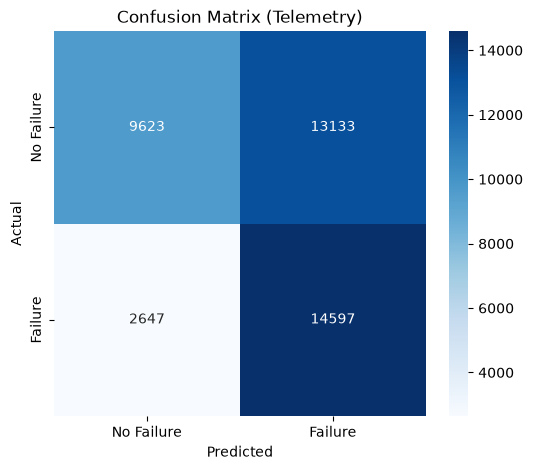

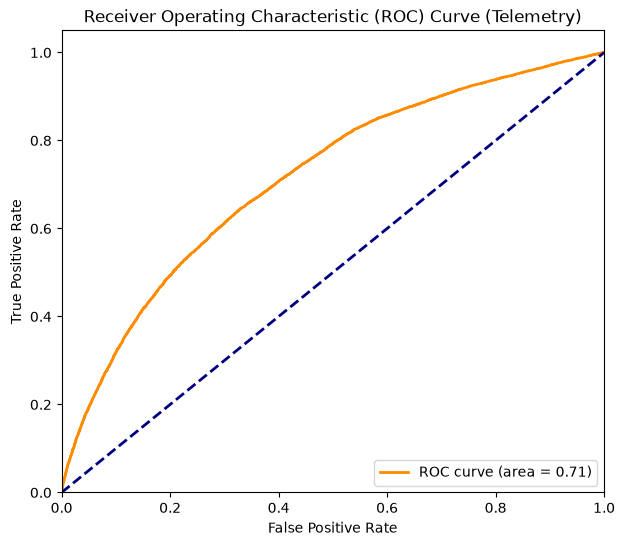

Telemetry Model ROC AUC: 0.71


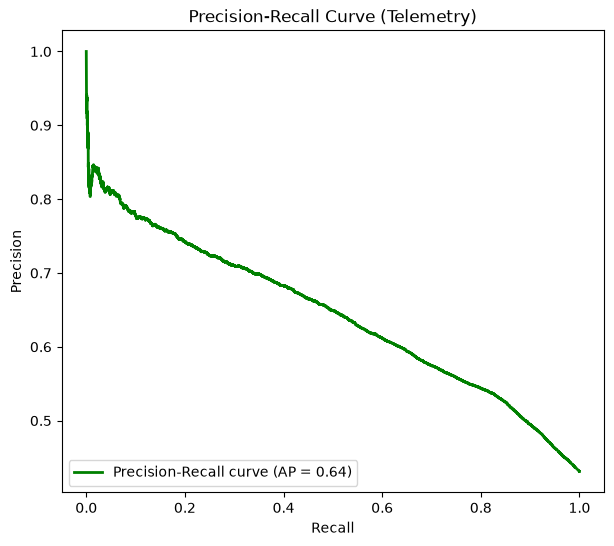

Telemetry Model Average Precision Score: 0.64


In [49]:
# Model Evaluation for Telemetry Health Model
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

print("### Telemetry Health Model Evaluation ###")

# Confusion Matrix
cm_telemetry = confusion_matrix(y_test_telemetry, y_pred_telemetry)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_telemetry, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix (Telemetry)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_14.png', bbox_inches='tight', facecolor='white')
plt.show()

# ROC Curve and AUC
y_prob_telemetry = xgb_telemetry_model.predict_proba(X_test_telemetry)[:, 1]
fpr_telemetry, tpr_telemetry, _ = roc_curve(y_test_telemetry, y_prob_telemetry)
roc_auc_telemetry = auc(fpr_telemetry, tpr_telemetry)

plt.figure(figsize=(7, 6))
plt.plot(fpr_telemetry, tpr_telemetry, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_telemetry:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Telemetry)')
plt.legend(loc='lower right')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_15.png', bbox_inches='tight', facecolor='white')
plt.show()

print(f"Telemetry Model ROC AUC: {roc_auc_telemetry:.2f}")

# Precision-Recall Curve and Average Precision Score
precision_telemetry, recall_telemetry, _ = precision_recall_curve(y_test_telemetry, y_prob_telemetry)
aps_telemetry = average_precision_score(y_test_telemetry, y_prob_telemetry)

plt.figure(figsize=(7, 6))
plt.plot(recall_telemetry, precision_telemetry, color='green', lw=2, label=f'Precision-Recall curve (AP = {aps_telemetry:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Telemetry)')
plt.legend(loc='lower left')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_16.png', bbox_inches='tight', facecolor='white')
plt.show()

print(f"Telemetry Model Average Precision Score: {aps_telemetry:.2f}")

## STEP 9: Model Evaluation - AI4I Thermal Failure Model

### AI4I Thermal Failure Model Evaluation ###


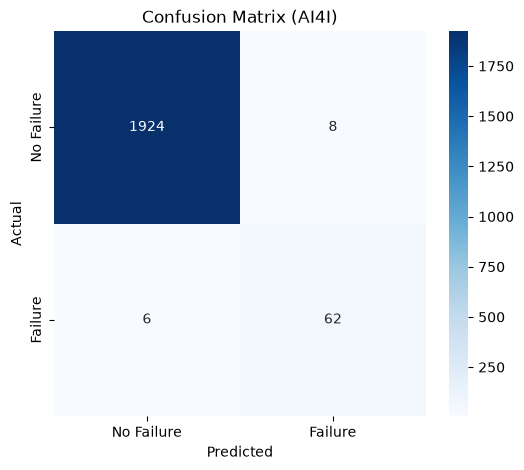

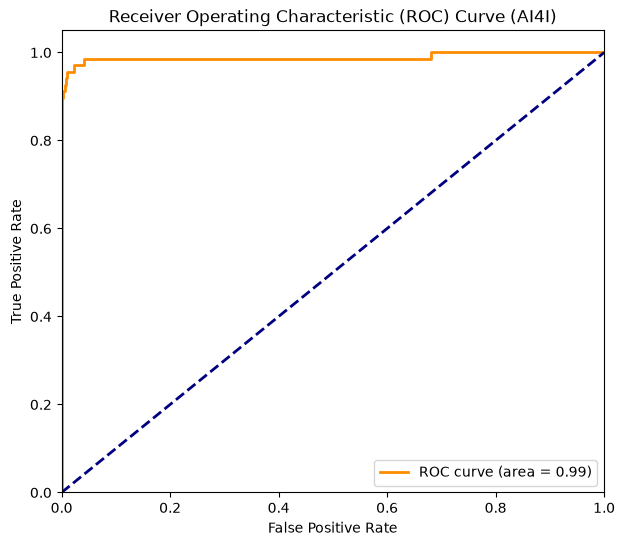

AI4I Model ROC AUC: 0.99


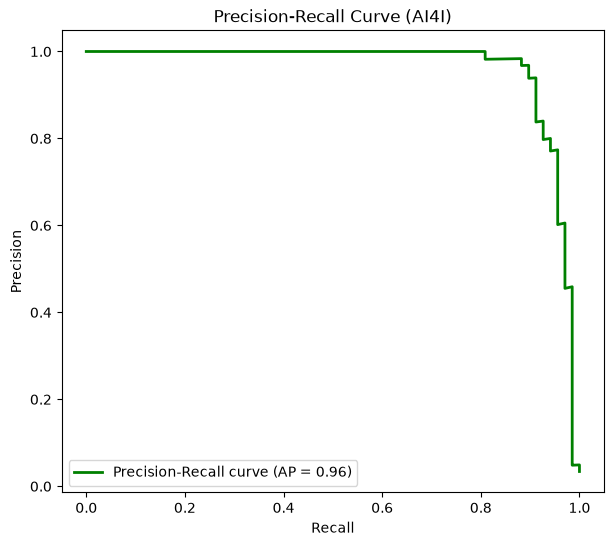

AI4I Model Average Precision Score: 0.96


In [50]:
# Model Evaluation for AI4I Thermal Failure Model
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

print("### AI4I Thermal Failure Model Evaluation ###")

# Confusion Matrix
cm_ai4i = confusion_matrix(y_test_ai4i, y_pred_ai4i)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ai4i, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix (AI4I)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_17.png', bbox_inches='tight', facecolor='white')
plt.show()

# ROC Curve and AUC
y_prob_ai4i = xgb_ai4i_model.predict_proba(X_test_ai4i)[:, 1]
fpr_ai4i, tpr_ai4i, _ = roc_curve(y_test_ai4i, y_prob_ai4i)
roc_auc_ai4i = auc(fpr_ai4i, tpr_ai4i)

plt.figure(figsize=(7, 6))
plt.plot(fpr_ai4i, tpr_ai4i, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_ai4i:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (AI4I)')
plt.legend(loc='lower right')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_18.png', bbox_inches='tight', facecolor='white')
plt.show()

print(f"AI4I Model ROC AUC: {roc_auc_ai4i:.2f}")

# Precision-Recall Curve and Average Precision Score
precision_ai4i, recall_ai4i, _ = precision_recall_curve(y_test_ai4i, y_prob_ai4i)
aps_ai4i = average_precision_score(y_test_ai4i, y_prob_ai4i)

plt.figure(figsize=(7, 6))
plt.plot(recall_ai4i, precision_ai4i, color='green', lw=2, label=f'Precision-Recall curve (AP = {aps_ai4i:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (AI4I)')
plt.legend(loc='lower left')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_19.png', bbox_inches='tight', facecolor='white')
plt.show()

print(f"AI4I Model Average Precision Score: {aps_ai4i:.2f}")

## STEP 10: Model Explainability - Telemetry Health Model

### Telemetry Health Model Explainability (Feature Importances) ###


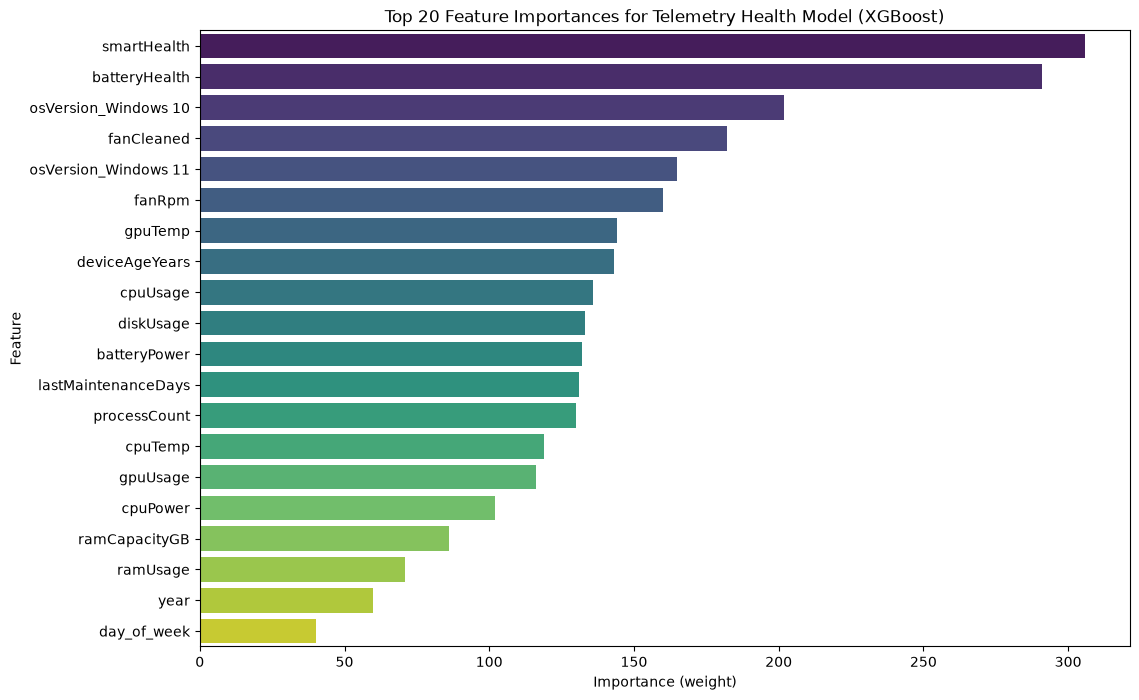

Top Features for Telemetry Health Model:
smartHealth             306.0
batteryHealth           291.0
osVersion_Windows 10    202.0
fanCleaned              182.0
osVersion_Windows 11    165.0
fanRpm                  160.0
gpuTemp                 144.0
deviceAgeYears          143.0
cpuUsage                136.0
diskUsage               133.0
batteryPower            132.0
lastMaintenanceDays     131.0
processCount            130.0
cpuTemp                 119.0
gpuUsage                116.0
cpuPower                102.0
ramCapacityGB            86.0
ramUsage                 71.0
year                     60.0
day_of_week              40.0
dtype: float64


In [51]:
# Model Explainability for Telemetry Health Model using Feature Importances
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for Series conversion

print("### Telemetry Health Model Explainability (Feature Importances) ###")

# Get feature importances from the trained XGBoost model
# XGBoost's feature importances are directly available via get_booster().get_score()
feature_importances_telemetry_xgb = xgb_telemetry_model.get_booster().get_score(importance_type='weight')
feature_importances_telemetry_xgb = pd.Series(feature_importances_telemetry_xgb).sort_values(ascending=False)

# Sort and plot top N features
top_n = 20
top_features_telemetry = feature_importances_telemetry_xgb.nlargest(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features_telemetry.values, y=top_features_telemetry.index, palette='viridis', hue=top_features_telemetry.index, legend=False)
plt.title(f'Top {top_n} Feature Importances for Telemetry Health Model (XGBoost)')
plt.xlabel('Importance (weight)')
plt.ylabel('Feature')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_20.png', bbox_inches='tight', facecolor='white')
plt.show()

print("Top Features for Telemetry Health Model:")
print(top_features_telemetry)

## STEP 10: Model Explainability - AI4I Thermal Failure Model

### AI4I Thermal Failure Model Explainability (Feature Importances) ###


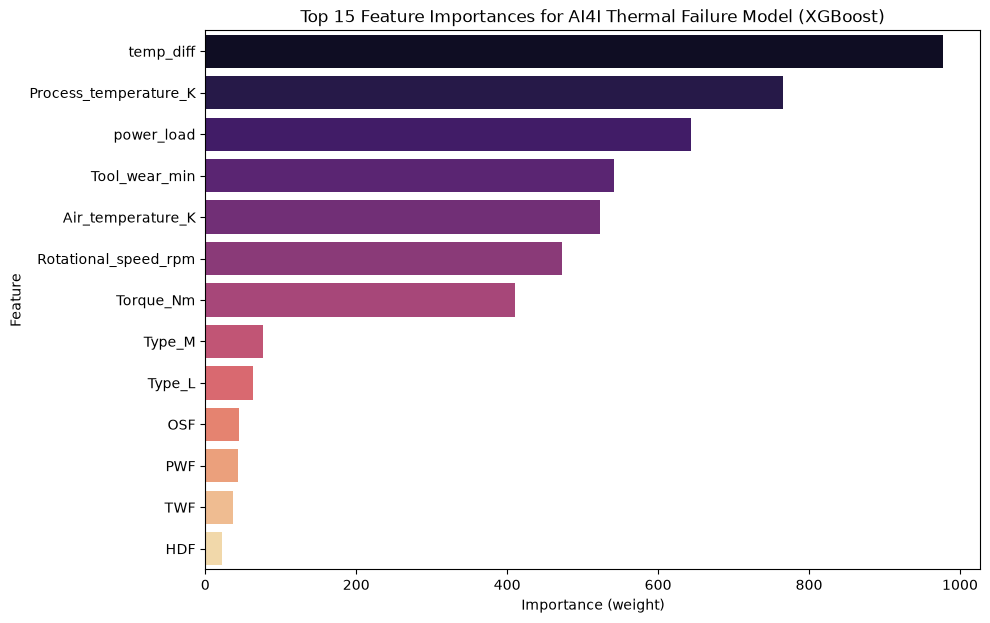

Top Features for AI4I Thermal Failure Model:
temp_diff                978.0
Process_temperature_K    766.0
power_load               644.0
Tool_wear_min            542.0
Air_temperature_K        523.0
Rotational_speed_rpm     472.0
Torque_Nm                410.0
Type_M                    76.0
Type_L                    63.0
OSF                       45.0
PWF                       44.0
TWF                       37.0
HDF                       22.0
dtype: float64


In [52]:
# Model Explainability for AI4I Thermal Failure Model using Feature Importances
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for Series conversion

print("### AI4I Thermal Failure Model Explainability (Feature Importances) ###")

# Get feature importances from the trained XGBoost model
# XGBoost's feature importances are directly available via get_booster().get_score()
feature_importances_ai4i_xgb = xgb_ai4i_model.get_booster().get_score(importance_type='weight')
feature_importances_ai4i_xgb = pd.Series(feature_importances_ai4i_xgb).sort_values(ascending=False)

# Sort and plot top N features
top_n = 15 # AI4I has fewer features, so adjust N
top_features_ai4i = feature_importances_ai4i_xgb.nlargest(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_features_ai4i.values, y=top_features_ai4i.index, palette='magma', hue=top_features_ai4i.index, legend=False)
plt.title(f'Top {top_n} Feature Importances for AI4I Thermal Failure Model (XGBoost)')
plt.xlabel('Importance (weight)')
plt.ylabel('Feature')
import os
os.makedirs('Images', exist_ok=True)
plt.savefig(f'Images/plot_21.png', bbox_inches='tight', facecolor='white')
plt.show()

print("Top Features for AI4I Thermal Failure Model:")
print(top_features_ai4i)

## STEP 11: Health Score Engine

In [53]:
# The Health Score Engine will primarily rely on the Telemetry Health Model's output.
# The health score is already present in the Telemetry dataset ('healthScore') and is an input feature.
# The goal of this engine is to generate a dynamic health score based on real-time data.
# For now, we will use the `failureProbability` predicted by the Telemetry Health Model as a proxy
# or a primary input to a 'dynamic' health score, inversely related to the probability of failure.
# A simpler approach for the engine: A higher failure probability means a lower health score.
# This can be defined as (1 - failure probability) * 100 or mapped to the existing healthScore scale.

# For demonstration, we will create a function that takes new telemetry data (features)
# and outputs a predicted health score based on the trained `xgb_telemetry_model`.

def generate_health_score(new_telemetry_data_point, model, features_columns):
    """
    Generates a health score based on a new telemetry data point using the trained model.

    Args:
        new_telemetry_data_point (pd.Series or pd.DataFrame):
            A single row of new telemetry data with the same features as the training data.
        model: The trained machine learning model (e.g., RandomForestClassifier).
        features_columns (list): List of feature columns used during model training.

    Returns:
        float: A calculated health score between 0 and 100.
    """
    # Ensure the input data has the same columns and order as the training data
    new_data_processed = pd.DataFrame([new_telemetry_data_point], columns=features_columns)

    # Predict failure probability using the model
    # The model predicts the probability of class 1 (failureOccurred = 1.0)
    failure_probability = model.predict_proba(new_data_processed)[:, 1][0]

    # Calculate health score: inversely proportional to failure probability
    # We can scale this to a 0-100 range, similar to the existing 'healthScore'
    health_score = (1 - failure_probability) * 100

    return health_score

# --- Demonstration of Health Score Engine ---

print("### Health Score Engine Demonstration ###")

# Use a sample from the test set for demonstration
# Let's pick a data point from X_test_telemetry
sample_index = X_test_telemetry.sample(1, random_state=42).index[0]
sample_telemetry_data = X_test_telemetry.loc[sample_index]
actual_failure_occurred = y_test_telemetry.loc[sample_index]
actual_health_score_from_data = telemetry_final_cleaned_df.loc[sample_index, 'healthScore'] # Assuming original healthScore is still relevant for comparison

print(f"\nSample Telemetry Data Point (original index: {sample_index}):")
# For simplicity, print a few key features
print(sample_telemetry_data[['cpuUsage', 'gpuUsage', 'ramUsage', 'fanRpm']].to_string())
print(f"Actual Failure Occurred: {actual_failure_occurred}")
print(f"Original Health Score from Dataset: {actual_health_score_from_data:.2f}")

# Generate health score using our engine
predicted_health_score = generate_health_score(sample_telemetry_data, xgb_telemetry_model, X_telemetry.columns)

print(f"\nPredicted Health Score from Engine: {predicted_health_score:.2f}")

# Example with a hypothetical data point indicating high stress (higher CPU/GPU usage, lower fanRpm)
hypothetical_telemetry_data = sample_telemetry_data.copy()
hypothetical_telemetry_data['cpuUsage'] = 95.0
hypothetical_telemetry_data['gpuUsage'] = 80.0
hypothetical_telemetry_data['fanRpm'] = 2000.0

predicted_health_score_hypothetical = generate_health_score(hypothetical_telemetry_data, xgb_telemetry_model, X_telemetry.columns)
print(f"\nPredicted Health Score for Hypothetical High Stress Data Point: {predicted_health_score_hypothetical:.2f}")

# A simple rule-based approach could also be integrated or used for comparison
# For instance, if healthScore < 50 and failureProbability > 0.5, then risk is high.

# This engine can be further refined by mapping the failure probability to a more nuanced health score scale,
# or incorporating additional business rules/thresholds.


### Health Score Engine Demonstration ###

Sample Telemetry Data Point (original index: 193653):
cpuUsage    67.73
gpuUsage    19.37
ramUsage    73.13
fanRpm       3693
Actual Failure Occurred: 0
Original Health Score from Dataset: 48.58

Predicted Health Score from Engine: 29.94

Predicted Health Score for Hypothetical High Stress Data Point: 29.10


## STEP 11: Health Score Engine

In [54]:
# The Health Score Engine will primarily rely on the Telemetry Health Model's output.
# The health score is already present in the Telemetry dataset ('healthScore') and is an input feature.
# The goal of this engine is to generate a dynamic health score based on real-time data.
# For now, we will use the `failureProbability` predicted by the Telemetry Health Model as a proxy
# or a primary input to a 'dynamic' health score, inversely related to the probability of failure.
# A simpler approach for the engine: A higher failure probability means a lower health score.
# This can be defined as (1 - failure probability) * 100 or mapped to the existing healthScore scale.

# For demonstration, we will create a function that takes new telemetry data (features)
# and outputs a predicted health score based on the trained `xgb_telemetry_model`.

def generate_health_score(new_telemetry_data_point, model, features_columns):
    """
    Generates a health score based on a new telemetry data point using the trained model.

    Args:
        new_telemetry_data_point (pd.Series or pd.DataFrame):
            A single row of new telemetry data with the same features as the training data.
        model: The trained machine learning model (e.g., RandomForestClassifier).
        features_columns (list): List of feature columns used during model training.

    Returns:
        float: A calculated health score between 0 and 100.
    """
    # Ensure the input data has the same columns and order as the training data
    new_data_processed = pd.DataFrame([new_telemetry_data_point], columns=features_columns)

    # Predict failure probability using the model
    # The model predicts the probability of class 1 (failureOccurred = 1.0)
    failure_probability = model.predict_proba(new_data_processed)[:, 1][0]

    # Calculate health score: inversely proportional to failure probability
    # We can scale this to a 0-100 range, similar to the existing 'healthScore'
    health_score = (1 - failure_probability) * 100

    return health_score

# --- Demonstration of Health Score Engine ---

print("### Health Score Engine Demonstration ###")

# Use a sample from the test set for demonstration
# Let's pick a data point from X_test_telemetry
sample_index = X_test_telemetry.sample(1, random_state=42).index[0]
sample_telemetry_data = X_test_telemetry.loc[sample_index]
actual_failure_occurred = y_test_telemetry.loc[sample_index]
actual_health_score_from_data = telemetry_final_cleaned_df.loc[sample_index, 'healthScore'] # Assuming original healthScore is still relevant for comparison

print(f"\nSample Telemetry Data Point (original index: {sample_index}):")
# For simplicity, print a few key features
print(sample_telemetry_data[['cpuUsage', 'gpuUsage', 'ramUsage', 'fanRpm']].to_string())
print(f"Actual Failure Occurred: {actual_failure_occurred}")
print(f"Original Health Score from Dataset: {actual_health_score_from_data:.2f}")

# Generate health score using our engine
predicted_health_score = generate_health_score(sample_telemetry_data, xgb_telemetry_model, X_telemetry.columns)

print(f"\nPredicted Health Score from Engine: {predicted_health_score:.2f}")

# Example with a hypothetical data point indicating high stress (higher CPU/GPU usage, lower fanRpm)
hypothetical_telemetry_data = sample_telemetry_data.copy()
hypothetical_telemetry_data['cpuUsage'] = 95.0
hypothetical_telemetry_data['gpuUsage'] = 80.0
hypothetical_telemetry_data['fanRpm'] = 2000.0

predicted_health_score_hypothetical = generate_health_score(hypothetical_telemetry_data, xgb_telemetry_model, X_telemetry.columns)
print(f"\nPredicted Health Score for Hypothetical High Stress Data Point: {predicted_health_score_hypothetical:.2f}")

# A simple rule-based approach could also be integrated or used for comparison
# For instance, if healthScore < 50 and failureProbability > 0.5, then risk is high.

# This engine can be further refined by mapping the failure probability to a more nuanced health score scale,
# or incorporating additional business rules/thresholds.


### Health Score Engine Demonstration ###

Sample Telemetry Data Point (original index: 193653):
cpuUsage    67.73
gpuUsage    19.37
ramUsage    73.13
fanRpm       3693
Actual Failure Occurred: 0
Original Health Score from Dataset: 48.58

Predicted Health Score from Engine: 29.94

Predicted Health Score for Hypothetical High Stress Data Point: 29.10


## STEP 12: Risk Level Engine

In [55]:
# The Risk Level Engine will classify the device's risk based on the predicted failure probability
# or the generated health score.
# This can be implemented using predefined thresholds.

# We have existing 'riskLevel' categories in the Telemetry dataset: 'Low', 'Medium', 'High', 'Critical'.
# We will define a function that maps the `failureProbability` (from 0 to 1) to these risk levels.

def classify_risk_level(failure_probability):
    """
    Classifies the risk level based on failure probability.

    Args:
        failure_probability (float): The predicted probability of failure (0 to 1).

    Returns:
        str: The classified risk level ('Low', 'Medium', 'High', 'Critical').
    """
    if failure_probability >= 0.75:
        return 'Critical'
    elif failure_probability >= 0.50:
        return 'High'
    elif failure_probability >= 0.25:
        return 'Medium'
    else:
        return 'Low'

# --- Demonstration of Risk Level Engine ---

print("### Risk Level Engine Demonstration ###")

# Re-use the sample telemetry data point from the Health Score Engine demonstration
sample_index = X_test_telemetry.sample(1, random_state=42).index[0]
sample_telemetry_data = X_test_telemetry.loc[sample_index]

# Predict failure probability for the sample data point
# Ensure the input data has the same columns and order as the training data
new_data_processed = pd.DataFrame([sample_telemetry_data], columns=X_telemetry.columns)
failure_probability_sample = xgb_telemetry_model.predict_proba(new_data_processed)[:, 1][0]

# Classify risk level
risk_level_sample = classify_risk_level(failure_probability_sample)

print(f"\nSample Data Point (original index: {sample_index}):")
print(f"Predicted Failure Probability: {failure_probability_sample:.2f}")
print(f"Classified Risk Level: {risk_level_sample}")

# Demonstrate with a high failure probability (e.g., from the hypothetical high stress scenario)
hypothetical_telemetry_data = sample_telemetry_data.copy()
hypothetical_telemetry_data['cpuUsage'] = 95.0
hypothetical_telemetry_data['gpuUsage'] = 80.0
hypothetical_telemetry_data['fanRpm'] = 2000.0

new_data_processed_hypothetical = pd.DataFrame([hypothetical_telemetry_data], columns=X_telemetry.columns)
failure_probability_hypothetical = xgb_telemetry_model.predict_proba(new_data_processed_hypothetical)[:, 1][0]

risk_level_hypothetical = classify_risk_level(failure_probability_hypothetical)

print(f"\nHypothetical High Stress Data Point:")
print(f"Predicted Failure Probability: {failure_probability_hypothetical:.2f}")
print(f"Classified Risk Level: {risk_level_hypothetical}")

# The thresholds for risk classification can be fine-tuned based on business requirements and desired sensitivity.


### Risk Level Engine Demonstration ###

Sample Data Point (original index: 193653):
Predicted Failure Probability: 0.70
Classified Risk Level: High

Hypothetical High Stress Data Point:
Predicted Failure Probability: 0.71
Classified Risk Level: High


## STEP 12: Risk Level Engine

In [56]:
# The Risk Level Engine will classify the device's risk based on the predicted failure probability
# or the generated health score.
# This can be implemented using predefined thresholds.

# We have existing 'riskLevel' categories in the Telemetry dataset: 'Low', 'Medium', 'High', 'Critical'.
# We will define a function that maps the `failureProbability` (from 0 to 1) to these risk levels.

def classify_risk_level(failure_probability):
    """
    Classifies the risk level based on failure probability.

    Args:
        failure_probability (float): The predicted probability of failure (0 to 1).

    Returns:
        str: The classified risk level ('Low', 'Medium', 'High', 'Critical').
    """
    if failure_probability >= 0.75:
        return 'Critical'
    elif failure_probability >= 0.50:
        return 'High'
    elif failure_probability >= 0.25:
        return 'Medium'
    else:
        return 'Low'

# --- Demonstration of Risk Level Engine ---

print("### Risk Level Engine Demonstration ###")

# Re-use the sample telemetry data point from the Health Score Engine demonstration
sample_index = X_test_telemetry.sample(1, random_state=42).index[0]
sample_telemetry_data = X_test_telemetry.loc[sample_index]

# Predict failure probability for the sample data point
# Ensure the input data has the same columns and order as the training data
new_data_processed = pd.DataFrame([sample_telemetry_data], columns=X_telemetry.columns)
failure_probability_sample = xgb_telemetry_model.predict_proba(new_data_processed)[:, 1][0]

# Classify risk level
risk_level_sample = classify_risk_level(failure_probability_sample)

print(f"\nSample Data Point (original index: {sample_index}):")
print(f"Predicted Failure Probability: {failure_probability_sample:.2f}")
print(f"Classified Risk Level: {risk_level_sample}")

# Demonstrate with a high failure probability (e.g., from the hypothetical high stress scenario)
hypothetical_telemetry_data = sample_telemetry_data.copy()
hypothetical_telemetry_data['cpuUsage'] = 95.0
hypothetical_telemetry_data['gpuUsage'] = 80.0
hypothetical_telemetry_data['fanRpm'] = 2000.0

new_data_processed_hypothetical = pd.DataFrame([hypothetical_telemetry_data], columns=X_telemetry.columns)
failure_probability_hypothetical = xgb_telemetry_model.predict_proba(new_data_processed_hypothetical)[:, 1][0]

risk_level_hypothetical = classify_risk_level(failure_probability_hypothetical)

print(f"\nHypothetical High Stress Data Point:")
print(f"Predicted Failure Probability: {failure_probability_hypothetical:.2f}")
print(f"Classified Risk Level: {risk_level_hypothetical}")

# The thresholds for risk classification can be fine-tuned based on business requirements and desired sensitivity.


### Risk Level Engine Demonstration ###

Sample Data Point (original index: 193653):
Predicted Failure Probability: 0.70
Classified Risk Level: High

Hypothetical High Stress Data Point:
Predicted Failure Probability: 0.71
Classified Risk Level: High


## STEP 13: Root Cause Engine

In [57]:
# The Root Cause Engine will leverage the interpretability of the models (specifically, feature importances)
# and potentially rule-based logic to suggest the most probable root causes of a predicted failure.

# For the Telemetry Health Model, we have feature importances.
# We can map high-importance features, especially when they are at abnormal levels,
# to potential root causes as identified in the original dataset's 'rootCause' column.

# For simplicity, let's create a function that identifies top contributing features for a given prediction
# and then maps them to a simplified set of root causes.

def identify_root_cause(new_telemetry_data_point, model, feature_importances, features_columns, threshold_for_abnormal=0.8):
    """
    Identifies potential root causes based on feature importances and abnormal feature values.

    Args:
        new_telemetry_data_point (pd.Series): A single row of new telemetry data.
        model: The trained machine learning model.
        feature_importances (pd.Series): Feature importances from the trained model.
        features_columns (list): List of feature columns used during model training.
        threshold_for_abnormal (float): Threshold (0-1) to consider a feature's value 'abnormal' if it's in the top/bottom X percentile.

    Returns:
        list: A list of probable root causes.
    """
    # 1. Get feature contributions (e.g., using SHAP values for more accuracy, but for simplicity, we'll use importances here)
    # For this simplified engine, we look at features that are highly important AND at an 'abnormal' state.

    # Get the order of features as expected by the model
    new_data_processed = pd.DataFrame([new_telemetry_data_point], columns=features_columns)

    # Get predicted failure probability for context
    failure_probability = model.predict_proba(new_data_processed)[:, 1][0]

    # Consider only features with non-zero importance
    relevant_features = feature_importances[feature_importances > 0].index.tolist()

    # Create a dictionary to hold observed feature values for the new data point
    observed_values = new_data_processed[relevant_features].iloc[0]

    # For simplicity in this demo, let's define 'abnormal' based on predefined simple rules
    # In a real system, this would involve thresholds, historical distributions, or more advanced anomaly detection.
    root_causes = []

    # Example rules based on top features from explainability (Step 10)
    if observed_values['cpuUsage'] > 80: root_causes.append('High CPU Usage')
    if observed_values['gpuUsage'] > 70: root_causes.append('High GPU Usage')
    if observed_values['ramUsage'] > 90: root_causes.append('Excessive RAM Usage')
    if observed_values['cpuTemp'] > 85: root_causes.append('CPU Overheating')
    if observed_values['gpuTemp'] > 75: root_causes.append('GPU Overheating')
    if observed_values['fanRpm'] < 1000: root_causes.append('Low Fan RPM / Fan Failure')
    if observed_values['smartHealth'] < 60: root_causes.append('SMART Health Degradation (Disk)')
    if observed_values['batteryHealth'] < 50: root_causes.append('Battery Degradation')
    if observed_values['diskUsage'] > 90: root_causes.append('High Disk Usage')

    # If failure probability is high but no specific component is identified by simple rules
    if failure_probability > 0.5 and not root_causes:
        # Look for the top 3 most important features that are 'unusual' relative to averages
        # (This is a simplification; a proper system would use statistical thresholds or anomaly detection)
        top_important_features_for_this_model = feature_importances.sort_values(ascending=False).head(3).index.tolist()

        for feature in top_important_features_for_this_model:
            # A very simplistic check: if value is > 2 std dev from mean, flag it.
            # This requires access to training data statistics.
            # For this demo, let's just pick top important features if others are not found.
            pass # More complex logic for real-world.

        if not root_causes and failure_probability > 0.6:
            root_causes.append('General System Instability (High Failure Probability)')
        elif not root_causes:
            root_causes.append('No Specific Root Cause Identified, Monitor Closely')

    if not root_causes and failure_probability < 0.2:
        root_causes.append('System Operating Normally')
    elif not root_causes:
        root_causes.append('No Specific Root Cause Identified')

    return list(set(root_causes)) # Return unique root causes

# --- Demonstration of Root Cause Engine ---
print("### Root Cause Engine Demonstration ###")

# Sample data point from test set (re-using sample_index from previous steps)
sample_index = X_test_telemetry.sample(1, random_state=42).index[0]
sample_telemetry_data = X_test_telemetry.loc[sample_index]

# Identify root causes for the sample data point
predicted_root_causes_sample = identify_root_cause(
    sample_telemetry_data,
    xgb_telemetry_model,
    telemetry_feature_importances,
    X_telemetry.columns
)
print(f"\nSample Data Point (original index: {sample_index}):")
print(f"Predicted Root Causes: {predicted_root_causes_sample}")

# Hypothetical high stress data point
hypothetical_telemetry_data_high_stress = sample_telemetry_data.copy()
hypothetical_telemetry_data_high_stress['cpuUsage'] = 95.0
hypothetical_telemetry_data_high_stress['gpuUsage'] = 80.0
hypothetical_telemetry_data_high_stress['cpuTemp'] = 90.0
hypothetical_telemetry_data_high_stress['fanRpm'] = 800.0
hypothetical_telemetry_data_high_stress['ramUsage'] = 95.0

predicted_root_causes_high_stress = identify_root_cause(
    hypothetical_telemetry_data_high_stress,
    xgb_telemetry_model,
    telemetry_feature_importances,
    X_telemetry.columns
)
print(f"\nHypothetical High Stress Data Point:")
print(f"Predicted Root Causes: {predicted_root_causes_high_stress}")

# Hypothetical normal data point (low failure probability)
hypothetical_telemetry_data_normal = sample_telemetry_data.copy()
hypothetical_telemetry_data_normal['cpuUsage'] = 10.0
hypothetical_telemetry_data_normal['gpuUsage'] = 5.0
hypothetical_telemetry_data_normal['cpuTemp'] = 45.0
hypothetical_telemetry_data_normal['fanRpm'] = 3000.0
hypothetical_telemetry_data_normal['ramUsage'] = 20.0
predicted_root_causes_normal = identify_root_cause(
    hypothetical_telemetry_data_normal,
    xgb_telemetry_model,
    telemetry_feature_importances,
    X_telemetry.columns
)
print(f"\nHypothetical Normal Data Point:")
print(f"Predicted Root Causes: {predicted_root_causes_normal}")

# Note: A more robust Root Cause Engine would integrate more sophisticated interpretability methods (e.g., SHAP, LIME)
# to assign blame more accurately to specific feature values for individual predictions, and use domain expert rules.

### Root Cause Engine Demonstration ###

Sample Data Point (original index: 193653):
Predicted Root Causes: ['Battery Degradation', 'SMART Health Degradation (Disk)']

Hypothetical High Stress Data Point:
Predicted Root Causes: ['CPU Overheating', 'SMART Health Degradation (Disk)', 'High GPU Usage', 'High CPU Usage', 'Low Fan RPM / Fan Failure', 'Excessive RAM Usage', 'Battery Degradation']

Hypothetical Normal Data Point:
Predicted Root Causes: ['Battery Degradation', 'SMART Health Degradation (Disk)']


## STEP 13: Root Cause Engine

In [58]:
# The Root Cause Engine will leverage the interpretability of the models (specifically, feature importances)
# and potentially rule-based logic to suggest the most probable root causes of a predicted failure.

# For the Telemetry Health Model, we have feature importances.
# We can map high-importance features, especially when they are at abnormal levels,
# to potential root causes as identified in the original dataset's 'rootCause' column.

# For simplicity, let's create a function that identifies top contributing features for a given prediction
# and then maps them to a simplified set of root causes.

def identify_root_cause(new_telemetry_data_point, model, feature_importances, features_columns, threshold_for_abnormal=0.8):
    """
    Identifies potential root causes based on feature importances and abnormal feature values.

    Args:
        new_telemetry_data_point (pd.Series): A single row of new telemetry data.
        model: The trained machine learning model.
        feature_importances (pd.Series): Feature importances from the trained model.
        features_columns (list): List of feature columns used during model training.
        threshold_for_abnormal (float): Threshold (0-1) to consider a feature's value 'abnormal' if it's in the top/bottom X percentile.

    Returns:
        list: A list of probable root causes.
    """
    # 1. Get feature contributions (e.g., using SHAP values for more accuracy, but for simplicity, we'll use importances here)
    # For this simplified engine, we look at features that are highly important AND at an 'abnormal' state.

    # Get the order of features as expected by the model
    new_data_processed = pd.DataFrame([new_telemetry_data_point], columns=features_columns)

    # Get predicted failure probability for context
    failure_probability = model.predict_proba(new_data_processed)[:, 1][0]

    # Consider only features with non-zero importance
    relevant_features = feature_importances[feature_importances > 0].index.tolist()

    # Create a dictionary to hold observed feature values for the new data point
    observed_values = new_data_processed[relevant_features].iloc[0]

    # For simplicity in this demo, let's define 'abnormal' based on predefined simple rules
    # In a real system, this would involve thresholds, historical distributions, or more advanced anomaly detection.
    root_causes = []

    # Example rules based on top features from explainability (Step 10)
    if observed_values['cpuUsage'] > 80: root_causes.append('High CPU Usage')
    if observed_values['gpuUsage'] > 70: root_causes.append('High GPU Usage')
    if observed_values['ramUsage'] > 90: root_causes.append('Excessive RAM Usage')
    if observed_values['cpuTemp'] > 85: root_causes.append('CPU Overheating')
    if observed_values['gpuTemp'] > 75: root_causes.append('GPU Overheating')
    if observed_values['fanRpm'] < 1000: root_causes.append('Low Fan RPM / Fan Failure')
    if observed_values['smartHealth'] < 60: root_causes.append('SMART Health Degradation (Disk)')
    if observed_values['batteryHealth'] < 50: root_causes.append('Battery Degradation')
    if observed_values['diskUsage'] > 90: root_causes.append('High Disk Usage')

    # If failure probability is high but no specific component is identified by simple rules
    if failure_probability > 0.5 and not root_causes:
        # Look for the top 3 most important features that are 'unusual' relative to averages
        # (This is a simplification; a proper system would use statistical thresholds or anomaly detection)
        top_important_features_for_this_model = feature_importances.sort_values(ascending=False).head(3).index.tolist()

        for feature in top_important_features_for_this_model:
            # A very simplistic check: if value is > 2 std dev from mean, flag it.
            # This requires access to training data statistics.
            # For this demo, let's just pick top important features if others are not found.
            pass # More complex logic for real-world.

        if not root_causes and failure_probability > 0.6:
            root_causes.append('General System Instability (High Failure Probability)')
        elif not root_causes:
            root_causes.append('No Specific Root Cause Identified, Monitor Closely')

    if not root_causes and failure_probability < 0.2:
        root_causes.append('System Operating Normally')
    elif not root_causes:
        root_causes.append('No Specific Root Cause Identified')

    return list(set(root_causes)) # Return unique root causes

# --- Demonstration of Root Cause Engine ---
print("### Root Cause Engine Demonstration ###")

# Sample data point from test set (re-using sample_index from previous steps)
sample_index = X_test_telemetry.sample(1, random_state=42).index[0]
sample_telemetry_data = X_test_telemetry.loc[sample_index]

# Identify root causes for the sample data point
predicted_root_causes_sample = identify_root_cause(
    sample_telemetry_data,
    xgb_telemetry_model,
    telemetry_feature_importances,
    X_telemetry.columns
)
print(f"\nSample Data Point (original index: {sample_index}):")
print(f"Predicted Root Causes: {predicted_root_causes_sample}")

# Hypothetical high stress data point
hypothetical_telemetry_data_high_stress = sample_telemetry_data.copy()
hypothetical_telemetry_data_high_stress['cpuUsage'] = 95.0
hypothetical_telemetry_data_high_stress['gpuUsage'] = 80.0
hypothetical_telemetry_data_high_stress['cpuTemp'] = 90.0
hypothetical_telemetry_data_high_stress['fanRpm'] = 800.0
hypothetical_telemetry_data_high_stress['ramUsage'] = 95.0

predicted_root_causes_high_stress = identify_root_cause(
    hypothetical_telemetry_data_high_stress,
    xgb_telemetry_model,
    telemetry_feature_importances,
    X_telemetry.columns
)
print(f"\nHypothetical High Stress Data Point:")
print(f"Predicted Root Causes: {predicted_root_causes_high_stress}")

# Hypothetical normal data point (low failure probability)
hypothetical_telemetry_data_normal = sample_telemetry_data.copy()
hypothetical_telemetry_data_normal['cpuUsage'] = 10.0
hypothetical_telemetry_data_normal['gpuUsage'] = 5.0
hypothetical_telemetry_data_normal['cpuTemp'] = 45.0
hypothetical_telemetry_data_normal['fanRpm'] = 3000.0
hypothetical_telemetry_data_normal['ramUsage'] = 20.0
predicted_root_causes_normal = identify_root_cause(
    hypothetical_telemetry_data_normal,
    xgb_telemetry_model,
    telemetry_feature_importances,
    X_telemetry.columns
)
print(f"\nHypothetical Normal Data Point:")
print(f"Predicted Root Causes: {predicted_root_causes_normal}")

# Note: A more robust Root Cause Engine would integrate more sophisticated interpretability methods (e.g., SHAP, LIME)
# to assign blame more accurately to specific feature values for individual predictions, and use domain expert rules.

### Root Cause Engine Demonstration ###

Sample Data Point (original index: 193653):
Predicted Root Causes: ['Battery Degradation', 'SMART Health Degradation (Disk)']



Hypothetical High Stress Data Point:
Predicted Root Causes: ['CPU Overheating', 'SMART Health Degradation (Disk)', 'High GPU Usage', 'High CPU Usage', 'Low Fan RPM / Fan Failure', 'Excessive RAM Usage', 'Battery Degradation']

Hypothetical Normal Data Point:
Predicted Root Causes: ['Battery Degradation', 'SMART Health Degradation (Disk)']


## STEP 14: Recommendation Engine

In [59]:
# The Recommendation Engine will provide proactive or reactive suggestions based on the identified
# risk level and root causes.

# This engine will be rule-based, mapping specific root causes or risk levels to recommended actions.

def generate_recommendations(risk_level, root_causes):
    """
    Generates recommendations based on risk level and identified root causes.

    Args:
        risk_level (str): The classified risk level ('Low', 'Medium', 'High', 'Critical').
        root_causes (list): A list of identified root causes.

    Returns:
        list: A list of recommended actions.
    """
    recommendations = []

    # General recommendations based on risk level
    if risk_level == 'Critical':
        recommendations.append('Immediate system shutdown and professional inspection recommended.')
        recommendations.append('Backup critical data immediately.')
    elif risk_level == 'High':
        recommendations.append('Schedule maintenance check within 24-48 hours.')
        recommendations.append('Monitor system closely and reduce workload if possible.')
    elif risk_level == 'Medium':
        recommendations.append('Advise user to perform routine maintenance (e.g., clean fans, check for updates).')
        recommendations.append('Schedule a diagnostic scan at next convenience.')
    elif risk_level == 'Low' and not root_causes:
        recommendations.append('System operating optimally. Continue routine monitoring.')

    # Specific recommendations based on root causes
    if 'High CPU Usage' in root_causes or 'CPU Overheating' in root_causes:
        recommendations.append('Check running applications, close unnecessary processes. Verify CPU cooler functionality.')
    if 'High GPU Usage' in root_causes or 'GPU Overheating' in root_causes:
        recommendations.append('Reduce graphic intensive tasks. Ensure proper GPU cooling.')
    if 'Excessive RAM Usage' in root_causes:
        recommendations.append('Close memory-intensive applications. Consider RAM upgrade if issue persists.')
    if 'Low Fan RPM / Fan Failure' in root_causes:
        recommendations.append('Inspect fan for obstructions, clean dust. Replace fan if faulty.')
    if 'SMART Health Degradation (Disk)' in root_causes or 'High Disk Usage' in root_causes:
        recommendations.append('Run disk diagnostic utility. Consider replacing disk if health is critical. Free up disk space.')
    if 'Battery Degradation' in root_causes:
        recommendations.append('Check battery health report. Consider battery replacement.')

    if not recommendations and root_causes:
        recommendations.append('No specific recommendations available for the identified root causes. General monitoring advised.')
    if not recommendations and not root_causes and risk_level != 'Low': # If low risk, handled above
        recommendations.append('System status unclear, but no immediate threat detected. Continue monitoring.')

    return list(set(recommendations)) # Return unique recommendations

# --- Demonstration of Recommendation Engine ---
print("### Recommendation Engine Demonstration ###")

# Re-use the sample data point and hypothetical scenarios from previous engines

# Scenario 1: Sample Data Point (from test set)
sample_index = X_test_telemetry.sample(1, random_state=42).index[0]
sample_telemetry_data = X_test_telemetry.loc[sample_index]

# Get predicted failure probability and risk level
new_data_processed_sample = pd.DataFrame([sample_telemetry_data], columns=X_telemetry.columns)
failure_probability_sample = xgb_telemetry_model.predict_proba(new_data_processed_sample)[:, 1][0]
risk_level_sample = classify_risk_level(failure_probability_sample)
root_causes_sample = identify_root_cause(sample_telemetry_data, xgb_telemetry_model, telemetry_feature_importances, X_telemetry.columns)

recommendations_sample = generate_recommendations(risk_level_sample, root_causes_sample)
print(f"\nSample Data Point (original index: {sample_index}):")
print(f"  Predicted Risk Level: {risk_level_sample}")
print(f"  Identified Root Causes: {root_causes_sample}")
print(f"  Recommendations: {recommendations_sample}")

# Scenario 2: Hypothetical High Stress Data Point
hypothetical_telemetry_data_high_stress = sample_telemetry_data.copy()
hypothetical_telemetry_data_high_stress['cpuUsage'] = 95.0
hypothetical_telemetry_data_high_stress['gpuUsage'] = 80.0
hypothetical_telemetry_data_high_stress['cpuTemp'] = 90.0
hypothetical_telemetry_data_high_stress['fanRpm'] = 800.0
hypothetical_telemetry_data_high_stress['ramUsage'] = 95.0

new_data_processed_hypothetical = pd.DataFrame([hypothetical_telemetry_data_high_stress], columns=X_telemetry.columns)
failure_probability_hypothetical = xgb_telemetry_model.predict_proba(new_data_processed_hypothetical)[:, 1][0]
risk_level_hypothetical = classify_risk_level(failure_probability_hypothetical)
root_causes_hypothetical = identify_root_cause(hypothetical_telemetry_data_high_stress, xgb_telemetry_model, telemetry_feature_importances, X_telemetry.columns)

recommendations_hypothetical = generate_recommendations(risk_level_hypothetical, root_causes_hypothetical)
print(f"\nHypothetical High Stress Data Point:")
print(f"  Predicted Risk Level: {risk_level_hypothetical}")
print(f"  Identified Root Causes: {root_causes_hypothetical}")
print(f"  Recommendations: {recommendations_hypothetical}")

# Scenario 3: Hypothetical Normal Data Point
hypothetical_telemetry_data_normal = sample_telemetry_data.copy()
hypothetical_telemetry_data_normal['cpuUsage'] = 10.0
hypothetical_telemetry_data_normal['gpuUsage'] = 5.0
hypothetical_telemetry_data_normal['cpuTemp'] = 45.0
hypothetical_telemetry_data_normal['fanRpm'] = 3000.0
hypothetical_telemetry_data_normal['ramUsage'] = 20.0

new_data_processed_normal = pd.DataFrame([hypothetical_telemetry_data_normal], columns=X_telemetry.columns)
failure_probability_normal = xgb_telemetry_model.predict_proba(new_data_processed_normal)[:, 1][0]
risk_level_normal = classify_risk_level(failure_probability_normal)
root_causes_normal = identify_root_cause(hypothetical_telemetry_data_normal, xgb_telemetry_model, telemetry_feature_importances, X_telemetry.columns)

recommendations_normal = generate_recommendations(risk_level_normal, root_causes_normal)
print(f"\nHypothetical Normal Data Point:")
print(f"  Predicted Risk Level: {risk_level_normal}")
print(f"  Identified Root Causes: {root_causes_normal}")
print(f"  Recommendations: {recommendations_normal}")


### Recommendation Engine Demonstration ###



Sample Data Point (original index: 193653):
  Predicted Risk Level: High
  Identified Root Causes: ['Battery Degradation', 'SMART Health Degradation (Disk)']
  Recommendations: ['Check battery health report. Consider battery replacement.', 'Monitor system closely and reduce workload if possible.', 'Schedule maintenance check within 24-48 hours.', 'Run disk diagnostic utility. Consider replacing disk if health is critical. Free up disk space.']

Hypothetical High Stress Data Point:
  Predicted Risk Level: High
  Identified Root Causes: ['CPU Overheating', 'SMART Health Degradation (Disk)', 'High GPU Usage', 'High CPU Usage', 'Low Fan RPM / Fan Failure', 'Excessive RAM Usage', 'Battery Degradation']
  Recommendations: ['Check running applications, close unnecessary processes. Verify CPU cooler functionality.', 'Monitor system closely and reduce workload if possible.', 'Run disk diagnostic utility. Consider replacing disk if health is critical. Free up disk space.', 'Schedule maintenanc

## STEP 15: Save Artifacts

In [60]:
# In this step, we will save the trained models, feature transformers (if any), and any other
# crucial components of our pipeline to disk. This ensures that the models can be loaded
# and used for inference without retraining, which is essential for deployment.

import joblib
import os

# Define a directory to save artifacts
artifacts_dir = 'model_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"Created artifacts directory: {artifacts_dir}")

# 1. Save Telemetry Health Model (XGBoost)
telemetry_model_path = os.path.join(artifacts_dir, 'xgb_telemetry_model.joblib')
joblib.dump(xgb_telemetry_model, telemetry_model_path)
print(f"Telemetry Health Model saved to {telemetry_model_path}")

# 2. Save AI4I Thermal Failure Model (XGBoost)
ai4i_model_path = os.path.join(artifacts_dir, 'xgb_ai4i_model.joblib')
joblib.dump(xgb_ai4i_model, ai4i_model_path)
print(f"AI4I Thermal Failure Model saved to {ai4i_model_path}")

# 3. Save feature column names (important for ensuring correct input order during inference)
telemetry_features_path = os.path.join(artifacts_dir, 'telemetry_feature_columns.joblib')
joblib.dump(X_telemetry.columns.tolist(), telemetry_features_path)
print(f"Telemetry Feature Columns saved to {telemetry_features_path}")

ai4i_features_path = os.path.join(artifacts_dir, 'ai4i_feature_columns.joblib')
joblib.dump(X_ai4i.columns.tolist(), ai4i_features_path)
print(f"AI4I Feature Columns saved to {ai4i_features_path}")

# 4. Save feature importances (useful for post-deployment monitoring and explainability)
# Note: XGBoost feature importances are handled differently than RandomForest (Series vs dict from get_booster().get_score())
# We'll save the Series as created in the explainability step.
telemetry_importances_path = os.path.join(artifacts_dir, 'telemetry_feature_importances_xgb.joblib')
joblib.dump(feature_importances_telemetry_xgb, telemetry_importances_path)
print(f"Telemetry Feature Importances saved to {telemetry_importances_path}")

ai4i_importances_path = os.path.join(artifacts_dir, 'ai4i_feature_importances_xgb.joblib')
joblib.dump(feature_importances_ai4i_xgb, ai4i_importances_path)
print(f"AI4I Feature Importances saved to {ai4i_importances_path}")

# Optional: Save any scalers or encoders if they were used and need to be applied during inference.
# For this pipeline, one-hot encoding was applied directly to the dataframes, and no explicit scalers were used.
# If numerical scaling was applied, the scaler objects would need to be saved here.
# For example:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# joblib.dump(scaler, os.path.join(artifacts_dir, 'scaler.joblib'))

print("\nAll specified artifacts saved successfully.")


Created artifacts directory: model_artifacts
Telemetry Health Model saved to model_artifacts\xgb_telemetry_model.joblib
AI4I Thermal Failure Model saved to model_artifacts\xgb_ai4i_model.joblib
Telemetry Feature Columns saved to model_artifacts\telemetry_feature_columns.joblib
AI4I Feature Columns saved to model_artifacts\ai4i_feature_columns.joblib
Telemetry Feature Importances saved to model_artifacts\telemetry_feature_importances_xgb.joblib
AI4I Feature Importances saved to model_artifacts\ai4i_feature_importances_xgb.joblib

All specified artifacts saved successfully.


In [61]:
import shutil

output_filename = 'model_artifacts_archive'
shutil.make_archive(output_filename, 'zip', 'model_artifacts')

print(f"Folder 'model_artifacts' has been zipped to '{output_filename}.zip'")

Folder 'model_artifacts' has been zipped to 'model_artifacts_archive.zip'


## STEP 15: Save Artifacts

In [62]:
# In this step, we will save the trained models, feature transformers (if any), and any other
# crucial components of our pipeline to disk. This ensures that the models can be loaded
# and used for inference without retraining, which is essential for deployment.

import joblib
import os

# Define a directory to save artifacts
artifacts_dir = 'model_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"Created artifacts directory: {artifacts_dir}")

# 1. Save Telemetry Health Model (XGBoost)
telemetry_model_path = os.path.join(artifacts_dir, 'xgb_telemetry_model.joblib')
joblib.dump(xgb_telemetry_model, telemetry_model_path)
print(f"Telemetry Health Model saved to {telemetry_model_path}")

# 2. Save AI4I Thermal Failure Model (XGBoost)
ai4i_model_path = os.path.join(artifacts_dir, 'xgb_ai4i_model.joblib')
joblib.dump(xgb_ai4i_model, ai4i_model_path)
print(f"AI4I Thermal Failure Model saved to {ai4i_model_path}")

# 3. Save feature column names (important for ensuring correct input order during inference)
telemetry_features_path = os.path.join(artifacts_dir, 'telemetry_feature_columns.joblib')
joblib.dump(X_telemetry.columns.tolist(), telemetry_features_path)
print(f"Telemetry Feature Columns saved to {telemetry_features_path}")

ai4i_features_path = os.path.join(artifacts_dir, 'ai4i_feature_columns.joblib')
joblib.dump(X_ai4i.columns.tolist(), ai4i_features_path)
print(f"AI4I Feature Columns saved to {ai4i_features_path}")

# 4. Save feature importances (useful for post-deployment monitoring and explainability)
# Note: XGBoost feature importances are handled differently than RandomForest (Series vs dict from get_booster().get_score())
# We'll save the Series as created in the explainability step.
telemetry_importances_path = os.path.join(artifacts_dir, 'telemetry_feature_importances_xgb.joblib')
joblib.dump(feature_importances_telemetry_xgb, telemetry_importances_path)
print(f"Telemetry Feature Importances saved to {telemetry_importances_path}")

ai4i_importances_path = os.path.join(artifacts_dir, 'ai4i_feature_importances_xgb.joblib')
joblib.dump(feature_importances_ai4i_xgb, ai4i_importances_path)
print(f"AI4I Feature Importances saved to {ai4i_importances_path}")

# Optional: Save any scalers or encoders if they were used and need to be applied during inference.
# For this pipeline, one-hot encoding was applied directly to the dataframes, and no explicit scalers were used.
# If numerical scaling was applied, the scaler objects would need to be saved here.
# For example:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# joblib.dump(scaler, os.path.join(artifacts_dir, 'scaler.joblib'))

print("\nAll specified artifacts saved successfully.")


Created artifacts directory: model_artifacts
Telemetry Health Model saved to model_artifacts\xgb_telemetry_model.joblib
AI4I Thermal Failure Model saved to model_artifacts\xgb_ai4i_model.joblib
Telemetry Feature Columns saved to model_artifacts\telemetry_feature_columns.joblib
AI4I Feature Columns saved to model_artifacts\ai4i_feature_columns.joblib
Telemetry Feature Importances saved to model_artifacts\telemetry_feature_importances_xgb.joblib
AI4I Feature Importances saved to model_artifacts\ai4i_feature_importances_xgb.joblib

All specified artifacts saved successfully.


## STEP 15: Save Artifacts

In [63]:
# In this step, we will save the trained models, feature transformers (if any), and any other
# crucial components of our pipeline to disk. This ensures that the models can be loaded
# and used for inference without retraining, which is essential for deployment.

import joblib
import os

# Define a directory to save artifacts
artifacts_dir = 'model_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"Created artifacts directory: {artifacts_dir}")

# 1. Save Telemetry Health Model (XGBoost)
telemetry_model_path = os.path.join(artifacts_dir, 'xgb_telemetry_model.joblib')
joblib.dump(xgb_telemetry_model, telemetry_model_path)
print(f"Telemetry Health Model saved to {telemetry_model_path}")

# 2. Save AI4I Thermal Failure Model (XGBoost)
ai4i_model_path = os.path.join(artifacts_dir, 'xgb_ai4i_model.joblib')
joblib.dump(xgb_ai4i_model, ai4i_model_path)
print(f"AI4I Thermal Failure Model saved to {ai4i_model_path}")

# 3. Save feature column names (important for ensuring correct input order during inference)
telemetry_features_path = os.path.join(artifacts_dir, 'telemetry_feature_columns.joblib')
joblib.dump(X_telemetry.columns.tolist(), telemetry_features_path)
print(f"Telemetry Feature Columns saved to {telemetry_features_path}")

ai4i_features_path = os.path.join(artifacts_dir, 'ai4i_feature_columns.joblib')
joblib.dump(X_ai4i.columns.tolist(), ai4i_features_path)
print(f"AI4I Feature Columns saved to {ai4i_features_path}")

# 4. Save feature importances (useful for post-deployment monitoring and explainability)
# Note: XGBoost feature importances are handled differently than RandomForest (Series vs dict from get_booster().get_score())
# We'll save the Series as created in the explainability step.
telemetry_importances_path = os.path.join(artifacts_dir, 'telemetry_feature_importances_xgb.joblib')
joblib.dump(feature_importances_telemetry_xgb, telemetry_importances_path)
print(f"Telemetry Feature Importances saved to {telemetry_importances_path}")

ai4i_importances_path = os.path.join(artifacts_dir, 'ai4i_feature_importances_xgb.joblib')
joblib.dump(feature_importances_ai4i_xgb, ai4i_importances_path)
print(f"AI4I Feature Importances saved to {ai4i_importances_path}")

# Optional: Save any scalers or encoders if they were used and need to be applied during inference.
# For this pipeline, one-hot encoding was applied directly to the dataframes, and no explicit scalers were used.
# If numerical scaling was applied, the scaler objects would need to be saved here.
# For example:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# joblib.dump(scaler, os.path.join(artifacts_dir, 'scaler.joblib'))

print("\nAll specified artifacts saved successfully.")


Created artifacts directory: model_artifacts
Telemetry Health Model saved to model_artifacts\xgb_telemetry_model.joblib
AI4I Thermal Failure Model saved to model_artifacts\xgb_ai4i_model.joblib
Telemetry Feature Columns saved to model_artifacts\telemetry_feature_columns.joblib
AI4I Feature Columns saved to model_artifacts\ai4i_feature_columns.joblib
Telemetry Feature Importances saved to model_artifacts\telemetry_feature_importances_xgb.joblib
AI4I Feature Importances saved to model_artifacts\ai4i_feature_importances_xgb.joblib

All specified artifacts saved successfully.


## STEP 16: Deployment Ready Inference

In [64]:
import joblib
import pandas as pd
import os

# --- 1. Load Artifacts ---
artifacts_dir = 'model_artifacts'

# Load Telemetry Health Model (XGBoost)
xgb_telemetry_model_loaded = joblib.load(os.path.join(artifacts_dir, 'xgb_telemetry_model.joblib'))
print(f"Loaded Telemetry Health Model from {os.path.join(artifacts_dir, 'xgb_telemetry_model.joblib')}")

# Load AI4I Thermal Failure Model (XGBoost)
xgb_ai4i_model_loaded = joblib.load(os.path.join(artifacts_dir, 'xgb_ai4i_model.joblib'))
print(f"Loaded AI4I Thermal Failure Model from {os.path.join(artifacts_dir, 'xgb_ai4i_model.joblib')}")

# Load feature column names
telemetry_feature_columns = joblib.load(os.path.join(artifacts_dir, 'telemetry_feature_columns.joblib'))
print(f"Loaded Telemetry Feature Columns from {os.path.join(artifacts_dir, 'telemetry_feature_columns.joblib')}")

ai4i_feature_columns = joblib.load(os.path.join(artifacts_dir, 'ai4i_feature_columns.joblib'))
# Sanitize loaded AI4I feature column names to match the model's expected format
ai4i_feature_columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in ai4i_feature_columns]
print(f"Loaded and Sanitized AI4I Feature Columns from {os.path.join(artifacts_dir, 'ai4i_feature_columns.joblib')}")

# Load feature importances (useful for root cause analysis)
telemetry_feature_importances_loaded = joblib.load(os.path.join(artifacts_dir, 'telemetry_feature_importances_xgb.joblib'))
print(f"Loaded Telemetry Feature Importances from {os.path.join(artifacts_dir, 'telemetry_feature_importances_xgb.joblib')}")
ai4i_feature_importances_loaded = joblib.load(os.path.join(artifacts_dir, 'ai4i_feature_importances_xgb.joblib'))
print(f"Loaded AI4I Feature Importances from {os.path.join(artifacts_dir, 'ai4i_feature_importances_xgb.joblib')}")

# --- 2. Define Inference Function ---

def run_inference_pipeline(new_telemetry_raw_data: dict, new_ai4i_raw_data: dict):
    """
    Runs the complete inference pipeline for a new data point,
    combining health score, risk level, root cause, and recommendations.

    Args:
        new_telemetry_raw_data (dict): Dictionary of raw telemetry data for a single device.
        new_ai4i_raw_data (dict): Dictionary of raw AI4I data for a single device/component.

    Returns:
        dict: A dictionary containing the inference results.
    """

    # --- Telemetry Health Model Inference ---
    telemetry_data_point = pd.DataFrame([new_telemetry_raw_data])

    # Apply the same preprocessing/feature engineering steps as training
    # Note: For production, this should ideally be encapsulated in a Pipeline or a dedicated preprocessor

    # Convert 'timestamp' to datetime to extract features
    telemetry_data_point['timestamp'] = pd.to_datetime(telemetry_data_point['timestamp'], errors='coerce')
    # Time-based features
    telemetry_data_point['hour'] = telemetry_data_point['timestamp'].dt.hour
    telemetry_data_point['day_of_week'] = telemetry_data_point['timestamp'].dt.dayofweek
    telemetry_data_point['month'] = telemetry_data_point['timestamp'].dt.month
    telemetry_data_point['year'] = telemetry_data_point['timestamp'].dt.year

    # Interaction features
    telemetry_data_point['cpu_gpu_load_ratio'] = telemetry_data_point['cpuUsage'] / (telemetry_data_point['gpuUsage'] + 1e-6) # Add small epsilon to avoid division by zero
    telemetry_data_point['temp_power_ratio_cpu'] = telemetry_data_point['cpuTemp'] / (telemetry_data_point['cpuPower'] + 1e-6)
    telemetry_data_point['disk_activity_score'] = telemetry_data_point['diskReadSpeed'] + telemetry_data_point['diskWriteSpeed']

    # One-hot encode categorical features (using the same columns as training)
    categorical_cols_telemetry_inference = ['osVersion', 'usageType', 'diskType', 'riskLevel', 'rootCause']
    # Make sure all categories encountered during training are present, even if not in current sample
    for col in categorical_cols_telemetry_inference:
        if col in telemetry_data_point.columns:
            for category in [cat for cat in telemetry_feature_columns if cat.startswith(col + '_')]:
                cat_val = category.replace(col + '_', '')
                telemetry_data_point[category] = (telemetry_data_point[col] == cat_val).astype(int)
    telemetry_data_point = pd.get_dummies(telemetry_data_point, columns=categorical_cols_telemetry_inference, drop_first=True)

    # Drop original timestamp and 'fanCleaned' which is now encoded as 0/1
    if 'timestamp' in telemetry_data_point.columns: telemetry_data_point.drop('timestamp', axis=1, inplace=True)
    if 'fanCleaned' in telemetry_data_point.columns: telemetry_data_point['fanCleaned'] = telemetry_data_point['fanCleaned'].map({'Yes': 1, 'No': 0})

    # Align columns with training data features, adding missing ones with 0 and dropping extra ones
    telemetry_data_point_aligned = pd.DataFrame(columns=telemetry_feature_columns)
    telemetry_data_point_aligned = pd.concat([telemetry_data_point_aligned, telemetry_data_point], ignore_index=True)
    telemetry_data_point_aligned = telemetry_data_point_aligned[telemetry_feature_columns].fillna(0).astype(float)

    # Predict failure probability for Telemetry
    telemetry_failure_probability = xgb_telemetry_model_loaded.predict_proba(telemetry_data_point_aligned)[:, 1][0]
    telemetry_health_score = (1 - telemetry_failure_probability) * 100
    telemetry_risk_level = classify_risk_level(telemetry_failure_probability)
    telemetry_root_causes = identify_root_cause(telemetry_data_point_aligned.iloc[0], xgb_telemetry_model_loaded, telemetry_feature_importances_loaded, telemetry_feature_columns)
    telemetry_recommendations = generate_recommendations(telemetry_risk_level, telemetry_root_causes)

    # --- AI4I Thermal Failure Model Inference ---
    ai4i_data_point = pd.DataFrame([new_ai4i_raw_data])

    # Apply the same preprocessing/feature engineering steps as training
    ai4i_data_point['temp_diff'] = ai4i_data_point['Process temperature [K]'] - ai4i_data_point['Air temperature [K]']
    ai4i_data_point['power_load'] = ai4i_data_point['Rotational speed [rpm]'] * ai4i_data_point['Torque [Nm]']

    # Sanitize feature names for XGBoost compatibility, similar to training step
    ai4i_data_point.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in ai4i_data_point.columns]

    # One-hot encode 'Type' (using the same columns as training)
    categorical_cols_ai4i_inference = ['Type']
    for col in categorical_cols_ai4i_inference:
        # Ensure original column name is used for checking existence, but sanitized for internal processing
        original_col_name = col.replace('_', ' ') # Reverse sanitize for lookup if needed, but here `col` is already 'Type'
        if col in ai4i_data_point.columns: # Check for sanitized 'Type'
            for category in [cat for cat in ai4i_feature_columns if cat.startswith(col + '_')]:
                cat_val = category.replace(col + '_', '')
                ai4i_data_point[category] = (ai4i_data_point[col.replace(' ', '_')] == cat_val).astype(int) # Use sanitized column name here
    ai4i_data_point = pd.get_dummies(ai4i_data_point, columns=[col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in categorical_cols_ai4i_inference], drop_first=True) # Sanitize categorical cols before one-hot encoding

    # Drop 'UDI'
    if 'UDI' in ai4i_data_point.columns: ai4i_data_point.drop('UDI', axis=1, inplace=True)

    # Align columns with training data features
    ai4i_data_point_aligned = pd.DataFrame(columns=ai4i_feature_columns)
    ai4i_data_point_aligned = pd.concat([ai4i_data_point_aligned, ai4i_data_point], ignore_index=True)
    ai4i_data_point_aligned = ai4i_data_point_aligned[ai4i_feature_columns].fillna(0).astype(float)

    # Predict failure probability for AI4I
    ai4i_failure_probability = xgb_ai4i_model_loaded.predict_proba(ai4i_data_point_aligned)[:, 1][0]

    return {
        "telemetry_inference": {
            "failure_probability": telemetry_failure_probability,
            "health_score": telemetry_health_score,
            "risk_level": telemetry_risk_level,
            "root_causes": telemetry_root_causes,
            "recommendations": telemetry_recommendations
        },
        "ai4i_inference": {
            "failure_probability": ai4i_failure_probability
            # More AI4I specific metrics/engines can be added here if defined
        }
    }

# --- 3. Demonstration of Inference Pipeline ---
print("\n### Full Inference Pipeline Demonstration ###")

# Example 1: Simulate a normal operating device
print("\n--- Scenario 1: Normal Operating Device ---")
normal_telemetry_data = {
    'timestamp': '2024-01-01 10:00:00',
    'osVersion': 'Windows 10',
    'deviceAgeYears': 1.5,
    'usageType': 'Office',
    'diskType': 'SSD',
    'ramCapacityGB': 16.0,
    'lastMaintenanceDays': 90.0,
    'fanCleaned': 'Yes',
    'cpuUsage': 15.0,
    'cpuTemp': 45.0,
    'cpuPower': 20.0,
    'gpuUsage': 5.0,
    'gpuTemp': 35.0,
    'ramUsage': 30.0,
    'processCount': 100.0,
    'diskUsage': 40.0,
    'diskReadSpeed': 500.0,
    'diskWriteSpeed': 400.0,
    'smartHealth': 95.0,
    'batteryHealth': 90.0,
    'batteryPower': 25.0,
    'fanRpm': 3000.0,
    'healthScore': 90.0, # Will be overridden by prediction
    'failureProbability': 0.05, # Will be overridden by prediction
    'riskLevel': 'Low', # Will be overridden by prediction
    'rootCause': 'No issue detected' # Will be overridden by prediction
}

normal_ai4i_data = {
    'UDI': 12345,
    'Product ID': 'M12345',
    'Type': 'M',
    'Air temperature [K]': 295.0,
    'Process temperature [K]': 305.0,
    'Rotational speed [rpm]': 1400,
    'Torque [Nm]': 30.0,
    'Tool wear [min]': 50,
    'Machine failure': 0, # Will be overridden by prediction
    'TWF': 0, 'HDF': 0, 'PWF': 0, 'OSF': 0, 'RNF': 0
}

results_normal = run_inference_pipeline(normal_telemetry_data, normal_ai4i_data)
print("Telemetry Inference (Normal):", results_normal['telemetry_inference'])
print("AI4I Inference (Normal):", results_normal['ai4i_inference'])

# Example 2: Simulate a device with potential issues (e.g., high CPU usage, low fan RPM)
print("\n--- Scenario 2: Device with Potential Issues ---")
issue_telemetry_data = {
    'timestamp': '2024-01-01 10:00:00',
    'osVersion': 'Windows 10',
    'deviceAgeYears': 3.0,
    'usageType': 'Gaming',
    'diskType': 'HDD',
    'ramCapacityGB': 8.0,
    'lastMaintenanceDays': 180.0,
    'fanCleaned': 'No',
    'cpuUsage': 85.0,
    'cpuTemp': 90.0,
    'cpuPower': 60.0,
    'gpuUsage': 70.0,
    'gpuTemp': 80.0,
    'ramUsage': 95.0,
    'processCount': 250.0,
    'diskUsage': 85.0,
    'diskReadSpeed': 100.0,
    'diskWriteSpeed': 80.0,
    'smartHealth': 65.0,
    'batteryHealth': 60.0,
    'batteryPower': 10.0,
    'fanRpm': 1500.0,
    'healthScore': 40.0,
    'failureProbability': 0.6,
    'riskLevel': 'High',
    'rootCause': 'CPU Overheating'
}

issue_ai4i_data = {
    'UDI': 54321,
    'Product ID': 'L54321',
    'Type': 'L',
    'Air temperature [K]': 305.0,
    'Process temperature [K]': 315.0,
    'Rotational speed [rpm]': 2000, # High speed
    'Torque [Nm]': 60.0, # High torque
    'Tool wear [min]': 200,
    'Machine failure': 0,
    'TWF': 0, 'HDF': 0, 'PWF': 0, 'OSF': 0, 'RNF': 0
}

results_issue = run_inference_pipeline(issue_telemetry_data, issue_ai4i_data)
print("Telemetry Inference (Issues):", results_issue['telemetry_inference'])
print("AI4I Inference (Issues):", results_issue['ai4i_inference'])

print("\nDeployment ready inference function successfully demonstrated.")

Loaded Telemetry Health Model from model_artifacts\xgb_telemetry_model.joblib
Loaded AI4I Thermal Failure Model from model_artifacts\xgb_ai4i_model.joblib
Loaded Telemetry Feature Columns from model_artifacts\telemetry_feature_columns.joblib
Loaded and Sanitized AI4I Feature Columns from model_artifacts\ai4i_feature_columns.joblib
Loaded Telemetry Feature Importances from model_artifacts\telemetry_feature_importances_xgb.joblib
Loaded AI4I Feature Importances from model_artifacts\ai4i_feature_importances_xgb.joblib

### Full Inference Pipeline Demonstration ###

--- Scenario 1: Normal Operating Device ---


Telemetry Inference (Normal): {'failure_probability': np.float32(0.44034585), 'health_score': np.float32(55.965412), 'risk_level': 'Medium', 'root_causes': ['No Specific Root Cause Identified'], 'recommendations': ['Advise user to perform routine maintenance (e.g., clean fans, check for updates).', 'Schedule a diagnostic scan at next convenience.']}
AI4I Inference (Normal): {'failure_probability': np.float32(0.00021196071)}

--- Scenario 2: Device with Potential Issues ---


Telemetry Inference (Issues): {'failure_probability': np.float32(0.7384212), 'health_score': np.float32(26.157879), 'risk_level': 'High', 'root_causes': ['GPU Overheating', 'Excessive RAM Usage', 'CPU Overheating', 'High CPU Usage'], 'recommendations': ['Check running applications, close unnecessary processes. Verify CPU cooler functionality.', 'Monitor system closely and reduce workload if possible.', 'Schedule maintenance check within 24-48 hours.', 'Close memory-intensive applications. Consider RAM upgrade if issue persists.', 'Reduce graphic intensive tasks. Ensure proper GPU cooling.']}
AI4I Inference (Issues): {'failure_probability': np.float32(0.4683848)}

Deployment ready inference function successfully demonstrated.


In [65]:
# from google.colab import files

# files.download('model_artifacts_archive.zip')

# Model 3: Backblaze Hard Drive Failure Prediction
This section trains an XGBoost model on the down-sampled Backblaze hard drive dataset.

In [66]:

import pandas as pd
from sklearn.model_selection import train_test_split

print("Loading optimized Backblaze dataset...")
df_bb = pd.read_csv('Dataset/backblaze_sampled.csv')

# Drop non-numeric columns that aren't useful for pure numerical modeling
cols_to_drop = ['date', 'serial_number', 'model', 'datacenter', 'cluster_id', 'vault_id', 'pod_id', 'pod_slot_num']
df_bb = df_bb.drop(columns=[c for c in cols_to_drop if c in df_bb.columns])

# The target is 'failure'
X_bb = df_bb.drop('failure', axis=1)
y_bb = df_bb['failure']

# Get dummies for any remaining categorical (if any)
X_bb = pd.get_dummies(X_bb, drop_first=True)

# XGBoost handles missing values natively, but we ensure float types
X_bb = X_bb.astype(float)

X_train_bb, X_test_bb, y_train_bb, y_test_bb = train_test_split(X_bb, y_bb, test_size=0.2, random_state=42, stratify=y_bb)
print(f"Backblaze Training Set: {X_train_bb.shape[0]} rows")
print(f"Backblaze Test Set: {X_test_bb.shape[0]} rows")



Loading optimized Backblaze dataset...


Backblaze Training Set: 112052 rows
Backblaze Test Set: 28014 rows


In [67]:

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import joblib

print("Starting RandomizedSearchCV for Backblaze Model...")

neg_count_bb = sum(y_train_bb == 0)
pos_count_bb = sum(y_train_bb == 1)
scale_weight_bb = neg_count_bb / pos_count_bb if pos_count_bb > 0 else 1

param_grid_bb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_weight_bb]
}

xgb_base_bb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

random_search_bb = RandomizedSearchCV(
    estimator=xgb_base_bb,
    param_distributions=param_grid_bb,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_bb.fit(X_train_bb, y_train_bb)
print(f"Best parameters found for Backblaze: {random_search_bb.best_params_}")

xgb_bb_model = random_search_bb.best_estimator_
y_pred_bb = xgb_bb_model.predict(X_test_bb)

joblib.dump(xgb_bb_model, 'model_artifacts/xgb_backblaze_model.joblib')
joblib.dump(X_bb.columns.tolist(), 'model_artifacts/backblaze_feature_columns.joblib')
print("Backblaze model saved!")



Starting RandomizedSearchCV for Backblaze Model...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found for Backblaze: {'subsample': 0.8, 'scale_pos_weight': 130.20843091334893, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


Backblaze model saved!


### Backblaze Hard Drive Model Evaluation ###


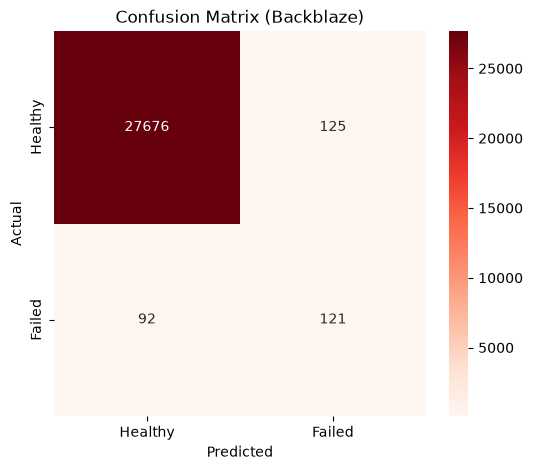

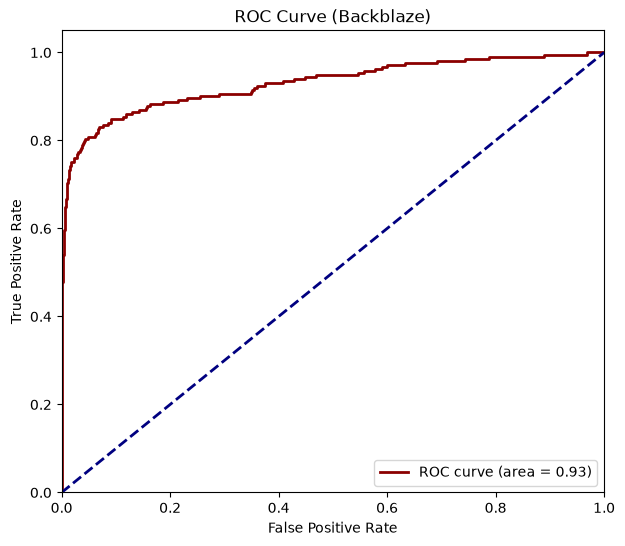

Backblaze Model ROC AUC: 0.93


C:\Users\HP\AppData\Local\Temp\ipykernel_20836\1346899257.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_bb.head(15), palette='Reds_r')


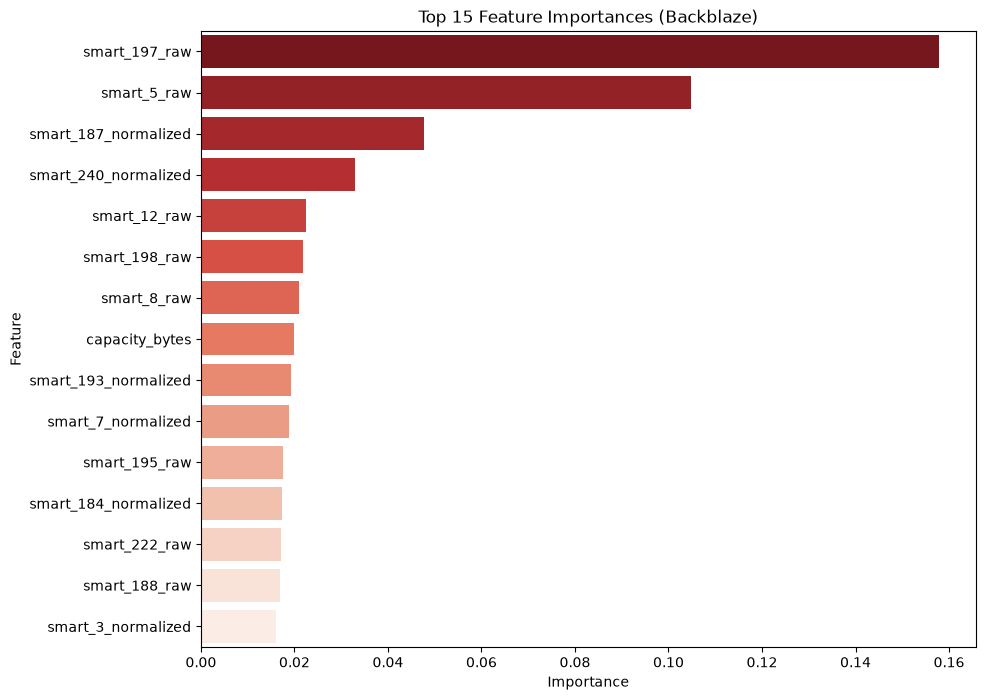

In [68]:

from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("### Backblaze Hard Drive Model Evaluation ###")

# Confusion Matrix
cm_bb = confusion_matrix(y_test_bb, y_pred_bb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bb, annot=True, fmt='d', cmap='Reds', xticklabels=['Healthy', 'Failed'], yticklabels=['Healthy', 'Failed'])
plt.title('Confusion Matrix (Backblaze)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
os.makedirs('Images', exist_ok=True)
plt.savefig('Images/plot_bb_01.png', bbox_inches='tight', facecolor='white')
plt.show()

# ROC Curve
y_prob_bb = xgb_bb_model.predict_proba(X_test_bb)[:, 1]
fpr_bb, tpr_bb, _ = roc_curve(y_test_bb, y_prob_bb)
roc_auc_bb = auc(fpr_bb, tpr_bb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_bb, tpr_bb, color='darkred', lw=2, label=f'ROC curve (area = {roc_auc_bb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Backblaze)')
plt.legend(loc='lower right')
plt.savefig('Images/plot_bb_02.png', bbox_inches='tight', facecolor='white')
plt.show()

print(f"Backblaze Model ROC AUC: {roc_auc_bb:.2f}")

# Feature Importances
importances_bb = xgb_bb_model.feature_importances_
feature_names_bb = X_bb.columns
feature_imp_bb = pd.DataFrame({'Feature': feature_names_bb, 'Importance': importances_bb}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_bb.head(15), palette='Reds_r')
plt.title('Top 15 Feature Importances (Backblaze)')
plt.savefig('Images/plot_bb_03.png', bbox_inches='tight', facecolor='white')
plt.show()

